In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [49]:
df = pd.read_csv("telco_churn_processed.csv")
df_raw = df.copy()

print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.829798,-1.160323,-0.994242,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,0
1,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-1.205113,-0.259629,-0.173244,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,True,0
2,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,-0.362660,-0.959674,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,1
3,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,-1.205113,-0.746535,-0.194766,True,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,0
4,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,0.197365,-0.940470,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,1


In [50]:
# Data quality report
missing_count = df.isna().sum().sort_values(ascending=False)
duplicate_count = df.duplicated().sum()

print("Data types summary:")
print(df.dtypes.value_counts())
print("\nTop missing values:")
print(missing_count[missing_count > 0].head(10))
print(f"\nDuplicate rows: {duplicate_count}")

# Convert boolean columns to integers for modeling consistency
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()
if bool_cols:
    df[bool_cols] = df[bool_cols].astype(int)

# Handle missing values
missing_before = int(df.isna().sum().sum())
if missing_before > 0:
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(exclude=[np.number]).columns

    if len(num_cols) > 0:
        df[num_cols] = df[num_cols].fillna(df[num_cols].median())

    for col in cat_cols:
        mode_values = df[col].mode(dropna=True)
        fill_value = mode_values.iloc[0] if not mode_values.empty else "Unknown"
        df[col] = df[col].fillna(fill_value)

missing_after = int(df.isna().sum().sum())
print(f"Missing values before imputation: {missing_before}")
print(f"Missing values after imputation: {missing_after}")

# Drop duplicates if present
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)

print(f"\nFinal shape after cleanup: {df.shape}")
df.head()

Data types summary:
bool       22
float64     8
int64       1
Name: count, dtype: int64

Top missing values:
Series([], dtype: int64)

Duplicate rows: 22
Missing values before imputation: 0
Missing values after imputation: 0

Final shape after cleanup: (7021, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.829798,-1.160323,-0.994242,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-1.205113,-0.259629,-0.173244,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
2,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,-0.362660,-0.959674,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,-1.205113,-0.746535,-0.194766,1,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,0.197365,-0.940470,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [51]:


if "df" not in globals():
    df = pd.read_csv("telco_churn_processed.csv")

df.info()
df.describe()
df["Churn"].value_counts(normalize=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7021 entries, 0 to 7020
Data columns (total 31 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   SeniorCitizen                          7021 non-null   float64
 1   Partner                                7021 non-null   float64
 2   Dependents                             7021 non-null   float64
 3   tenure                                 7021 non-null   float64
 4   PhoneService                           7021 non-null   float64
 5   PaperlessBilling                       7021 non-null   float64
 6   MonthlyCharges                         7021 non-null   float64
 7   TotalCharges                           7021 non-null   float64
 8   gender_Male                            7021 non-null   int64  
 9   MultipleLines_No phone service         7021 non-null   int64  
 10  MultipleLines_Yes                      7021 non-null   int64  
 11  Inte

Churn
0    0.735508
1    0.264492
Name: proportion, dtype: float64

In [52]:
# Encode categorical columns
if "df" not in globals():
    df = pd.read_csv("telco_churn_processed.csv")

cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()
target_col = "Churn"

# Keep target handling separate from feature encoding
feature_cat_cols = [c for c in cat_cols if c != target_col]

if feature_cat_cols:
    df = pd.get_dummies(df, columns=feature_cat_cols, drop_first=True, dtype=int)

# Encode target if it is still categorical
if target_col in df.columns and df[target_col].dtype == "object":
    target_mode = ["yes", "no", "true", "false", "1", "0"]
    unique_vals = [str(v).strip().lower() for v in df[target_col].dropna().unique()]

    if all(v in target_mode for v in unique_vals):
        df[target_col] = df[target_col].astype(str).str.strip().str.lower().map({
            "yes": 1, "true": 1, "1": 1,
            "no": 0, "false": 0, "0": 0
        })
    else:
        df[target_col] = df[target_col].astype("category").cat.codes

print(f"Encoded dataset shape: {df.shape}")
print("Remaining categorical columns:", df.select_dtypes(include=["object", "category"]).columns.tolist())
df.head()

Encoded dataset shape: (7021, 31)
Remaining categorical columns: []


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.439916,1.034530,-0.654012,-1.277445,-3.054010,0.829798,-1.160323,-0.994242,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,-0.439916,-0.966622,-0.654012,0.066327,0.327438,-1.205113,-0.259629,-0.173244,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
2,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,-0.362660,-0.959674,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,-0.439916,-0.966622,-0.654012,0.514251,-3.054010,-1.205113,-0.746535,-0.194766,1,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,-0.439916,-0.966622,-0.654012,-1.236724,0.327438,0.829798,0.197365,-0.940470,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [53]:
# Feature scaling for model-ready data
from sklearn.preprocessing import StandardScaler

if "df" not in globals():
    df = pd.read_csv("telco_churn_processed.csv")

df_model = df.copy()

# Ensure all features are numeric before scaling
cat_cols = df_model.select_dtypes(include=["object", "category"]).columns.tolist()
target_col = "Churn"

feature_cat_cols = [c for c in cat_cols if c != target_col]
if feature_cat_cols:
    df_model = pd.get_dummies(df_model, columns=feature_cat_cols, drop_first=True, dtype=int)

if target_col in df_model.columns and df_model[target_col].dtype == "object":
    df_model[target_col] = df_model[target_col].astype(str).str.strip().str.lower().map({
        "yes": 1, "true": 1, "1": 1,
        "no": 0, "false": 0, "0": 0
    })

feature_cols = [c for c in df_model.columns if c != target_col]
cols_to_scale = [
    c for c in feature_cols
    if pd.api.types.is_numeric_dtype(df_model[c]) and df_model[c].nunique() > 2
]

scaler = StandardScaler()
df_scaled = df_model.copy()
if cols_to_scale:
    df_scaled[cols_to_scale] = scaler.fit_transform(df_scaled[cols_to_scale])

print("Scaled columns:", cols_to_scale)
print("Scaled dataset shape:", df_scaled.shape)
df_scaled.head()

Scaled columns: ['tenure', 'MonthlyCharges', 'TotalCharges']
Scaled dataset shape: (7021, 31)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,gender_Male,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn
0,-0.439916,1.034530,-0.654012,-1.282728,-3.054010,0.829798,-1.164135,-0.997328,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
1,-0.439916,-0.966622,-0.654012,0.062387,0.327438,-1.205113,-0.262811,-0.176347,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,1,0
2,-0.439916,-0.966622,-0.654012,-1.241967,0.327438,0.829798,-0.365914,-0.962760,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,1
3,-0.439916,-0.966622,-0.654012,0.510759,-3.054010,-1.205113,-0.750058,-0.197869,1,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,-0.439916,-0.966622,-0.654012,-1.241967,0.327438,0.829798,0.194503,-0.943556,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1


In [54]:
# Feature engineering: 1) RFM 2) CLV + customer features
if "df_scaled" in globals():
    df_fe = df_scaled.copy()
elif "df" in globals():
    df_fe = df.copy()
else:
    df_fe = pd.read_csv("telco_churn_processed.csv")

# ---------- 1) RFM FEATURES ----------
tenure_col = "tenure" if "tenure" in df_fe.columns else None
monthly_col = "MonthlyCharges" if "MonthlyCharges" in df_fe.columns else None
total_col = "TotalCharges" if "TotalCharges" in df_fe.columns else None

# Ensure numeric types where needed
for col in [tenure_col, monthly_col, total_col]:
    if col is not None:
        df_fe[col] = pd.to_numeric(df_fe[col], errors="coerce")

if tenure_col is not None:
    max_tenure = df_fe[tenure_col].max()
    df_fe["Recency"] = (max_tenure - df_fe[tenure_col]).fillna(df_fe[tenure_col].median())
    df_fe["Frequency"] = df_fe[tenure_col].fillna(df_fe[tenure_col].median())
else:
    df_fe["Recency"] = 0.0
    df_fe["Frequency"] = 1.0

if total_col is not None:
    df_fe["Monetary"] = df_fe[total_col].fillna(df_fe[total_col].median())
elif monthly_col is not None and tenure_col is not None:
    df_fe["Monetary"] = (df_fe[monthly_col] * df_fe[tenure_col]).fillna(0)
elif monthly_col is not None:
    df_fe["Monetary"] = df_fe[monthly_col].fillna(df_fe[monthly_col].median())
else:
    df_fe["Monetary"] = 0.0

# ---------- 2) CLV + CUSTOMER FEATURES ----------
if monthly_col is not None and tenure_col is not None:
    # Simple historical CLV proxy for subscription data
    df_fe["CLV"] = (df_fe[monthly_col] * df_fe[tenure_col]).fillna(0)
else:
    df_fe["CLV"] = df_fe["Monetary"]

if monthly_col is not None and total_col is not None:
    df_fe["AvgMonthlyValue"] = (
        df_fe[total_col] / df_fe[tenure_col].replace(0, np.nan)
    ).fillna(df_fe[monthly_col])
else:
    df_fe["AvgMonthlyValue"] = df_fe["Monetary"]

if tenure_col is not None:
    df_fe["TenureGroup"] = pd.cut(
        df_fe[tenure_col],
        bins=[-1, 12, 24, 48, np.inf],
        labels=["New", "Early", "Established", "Loyal"]
    )
    df_fe["TenureGroup"] = df_fe["TenureGroup"].astype(str)
else:
    df_fe["TenureGroup"] = "Unknown"

df_fe["ARPU_to_Monetary"] = (
    df_fe["AvgMonthlyValue"] / (df_fe["Monetary"].replace(0, np.nan))
).fillna(0)

print("Added features: Recency, Frequency, Monetary, CLV, AvgMonthlyValue, TenureGroup, ARPU_to_Monetary")
print(f"Feature-engineered shape: {df_fe.shape}")
df_fe[["Recency", "Frequency", "Monetary", "CLV", "AvgMonthlyValue", "TenureGroup", "ARPU_to_Monetary"]].head()

Added features: Recency, Frequency, Monetary, CLV, AvgMonthlyValue, TenureGroup, ARPU_to_Monetary
Feature-engineered shape: (7021, 38)


,Recency,Frequency,Monetary,CLV,AvgMonthlyValue,TenureGroup,ARPU_to_Monetary
0,2.894035,-1.282728,-0.997328,1.493269,0.777505,nan,-0.779588
1,1.548920,0.062387,-0.176347,-0.016396,-2.826672,New,16.029008
2,2.853274,-1.241967,-0.962760,0.454454,0.775190,nan,-0.805174
3,1.100549,0.510759,-0.197869,-0.383099,-0.387402,New,1.957872
4,2.853274,-1.241967,-0.943556,-0.241567,0.759727,nan,-0.805174


In [55]:
df['Avg_Monthly_Spend'] = df['TotalCharges'] / (df['tenure'] + 1)
df['Tenure_Group'] = pd.cut(df['tenure'], bins=[0,12,24,48,72], labels=[0,1,2,3])
df['CLV'] = df['Avg_Monthly_Spend'] * df['tenure']

C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\3431447086.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=eda_df, x="ChurnLabel", palette="Set2")


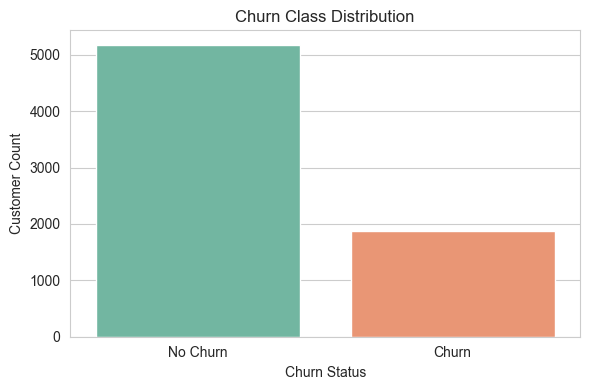

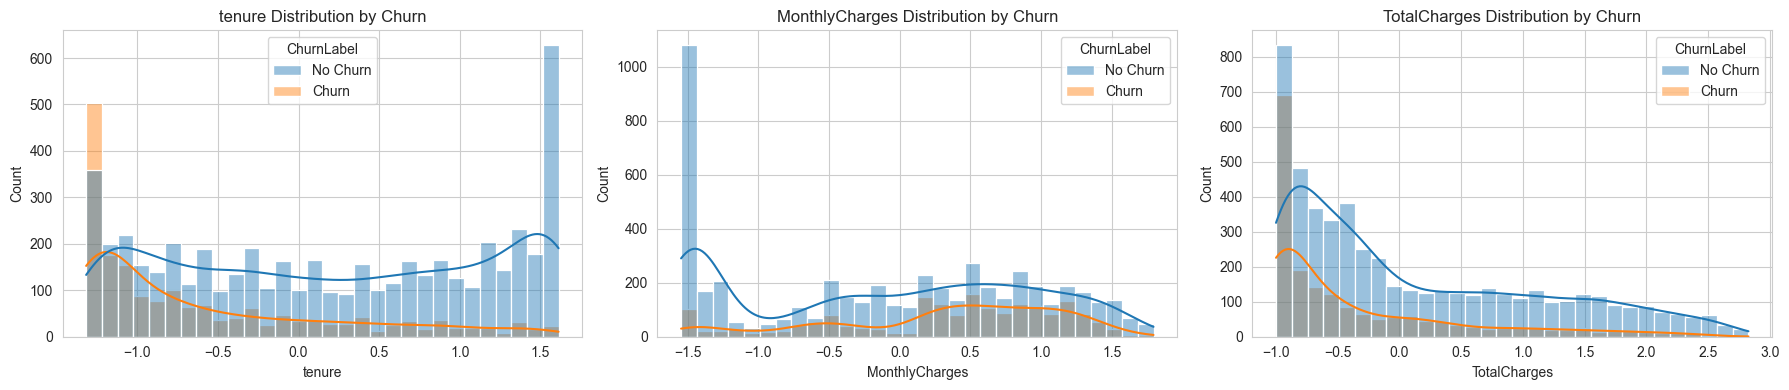

C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\3431447086.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rate_df, x=col, y="ChurnRate", palette="viridis")


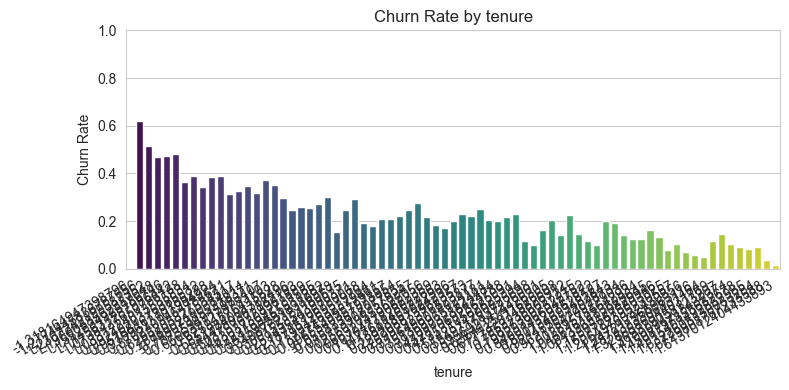

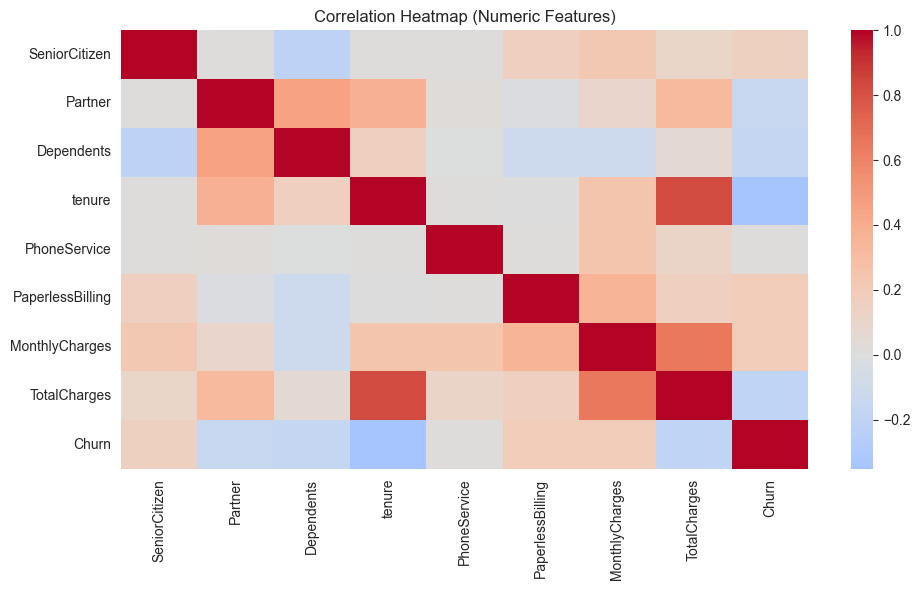

EDA completed: class balance, distributions, churn-rate bars, and correlation heatmap.


In [56]:
# Visual EDA for churn analysis
if "df_raw" in globals():
    eda_df = df_raw.copy()
elif "df" in globals():
    eda_df = df.copy()
else:
    eda_df = pd.read_csv("telco_churn_processed.csv")

# Standardize target label for plotting
if "Churn" in eda_df.columns:
    eda_df["ChurnLabel"] = eda_df["Churn"].astype(str).str.strip().str.lower().map({
        "yes": "Churn", "1": "Churn", "true": "Churn",
        "no": "No Churn", "0": "No Churn", "false": "No Churn"
    }).fillna(eda_df["Churn"].astype(str))
else:
    eda_df["ChurnLabel"] = "Unknown"

num_candidates = [c for c in ["tenure", "MonthlyCharges", "TotalCharges"] if c in eda_df.columns]
for c in num_candidates:
    eda_df[c] = pd.to_numeric(eda_df[c], errors="coerce")

# 1) Target distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=eda_df, x="ChurnLabel", palette="Set2")
plt.title("Churn Class Distribution")
plt.xlabel("Churn Status")
plt.ylabel("Customer Count")
plt.tight_layout()
plt.show()

# 2) Numeric feature distributions by churn
if num_candidates:
    fig, axes = plt.subplots(1, len(num_candidates), figsize=(6 * len(num_candidates), 4))
    if len(num_candidates) == 1:
        axes = [axes]

    for ax, col in zip(axes, num_candidates):
        sns.histplot(data=eda_df, x=col, hue="ChurnLabel", kde=True, bins=30, ax=ax, alpha=0.45)
        ax.set_title(f"{col} Distribution by Churn")

    plt.tight_layout()
    plt.show()

# 3) Churn rate across key categorical features
cat_priority = ["Contract", "InternetService", "PaymentMethod", "tenure", "Tenure_Group"]
cat_cols = [c for c in cat_priority if c in eda_df.columns]

for col in cat_cols[:4]:
    rate_df = (
        eda_df.groupby(col)["ChurnLabel"]
        .apply(lambda s: (s == "Churn").mean())
        .sort_values(ascending=False)
        .reset_index(name="ChurnRate")
    )

    plt.figure(figsize=(8, 4))
    sns.barplot(data=rate_df, x=col, y="ChurnRate", palette="viridis")
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

# 4) Correlation heatmap for numeric variables
num_df = eda_df.select_dtypes(include=[np.number]).copy()
if "Churn" in eda_df.columns and "Churn" not in num_df.columns:
    num_df["Churn"] = eda_df["ChurnLabel"].map({"No Churn": 0, "Churn": 1})

if not num_df.empty and num_df.shape[1] >= 2:
    plt.figure(figsize=(10, 6))
    corr = num_df.corr(numeric_only=True)
    sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
    plt.title("Correlation Heatmap (Numeric Features)")
    plt.tight_layout()
    plt.show()

print("EDA completed: class balance, distributions, churn-rate bars, and correlation heatmap.")

In [57]:
# ML Prep (separate step)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

if "df_fe" in globals():
    model_df = df_fe.copy()
elif "df_scaled" in globals():
    model_df = df_scaled.copy()
elif "df" in globals():
    model_df = df.copy()
else:
    model_df = pd.read_csv("telco_churn_processed.csv")

# Make target numeric and binary
if "Churn" not in model_df.columns:
    raise ValueError("Target column 'Churn' not found in dataset.")

if model_df["Churn"].dtype == "object":
    model_df["Churn"] = model_df["Churn"].astype(str).str.strip().str.lower().map({
        "yes": 1, "true": 1, "1": 1,
        "no": 0, "false": 0, "0": 0
    })

model_df = model_df.dropna(subset=["Churn"]).copy()
model_df["Churn"] = model_df["Churn"].astype(int)

# Encode any remaining categorical features
remaining_cat_cols = model_df.select_dtypes(include=["object", "category"]).columns.tolist()
remaining_cat_cols = [c for c in remaining_cat_cols if c != "Churn"]
if remaining_cat_cols:
    model_df = pd.get_dummies(model_df, columns=remaining_cat_cols, drop_first=True, dtype=int)

X = model_df.drop(columns=["Churn"])
y = model_df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model_results = []
print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (5616, 37) | Test shape: (1405, 37)


In [58]:
# Model 1: Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

logreg_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000, random_state=42))
])
logreg_model.fit(X_train, y_train)

logreg_pred = logreg_model.predict(X_test)
logreg_prob = logreg_model.predict_proba(X_test)[:, 1]

model_results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, logreg_pred),
    "Precision": precision_score(y_test, logreg_pred, zero_division=0),
    "Recall": recall_score(y_test, logreg_pred, zero_division=0),
    "F1": f1_score(y_test, logreg_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, logreg_prob)
})

print("Logistic Regression trained and evaluated.")

Logistic Regression trained and evaluated.


In [59]:
# Model 2: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

model_results.append({
    "Model": "Random Forest",
    "Accuracy": accuracy_score(y_test, rf_pred),
    "Precision": precision_score(y_test, rf_pred, zero_division=0),
    "Recall": recall_score(y_test, rf_pred, zero_division=0),
    "F1": f1_score(y_test, rf_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, rf_prob)
})

print("Random Forest trained and evaluated.")

Random Forest trained and evaluated.


In [60]:
# Model 3: XGBoost
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

model_results.append({
    "Model": "XGBoost",
    "Accuracy": accuracy_score(y_test, xgb_pred),
    "Precision": precision_score(y_test, xgb_pred, zero_division=0),
    "Recall": recall_score(y_test, xgb_pred, zero_division=0),
    "F1": f1_score(y_test, xgb_pred, zero_division=0),
    "ROC_AUC": roc_auc_score(y_test, xgb_prob)
})

print("XGBoost trained and evaluated.")

XGBoost trained and evaluated.


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.8028,0.6667,0.5108,0.5784,0.8402
1,XGBoost,0.7858,0.6237,0.4812,0.5432,0.8331
2,Random Forest,0.7900,0.6421,0.4677,0.5412,0.8272


C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\889753795.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Model", y="ROC_AUC", palette="Set2")


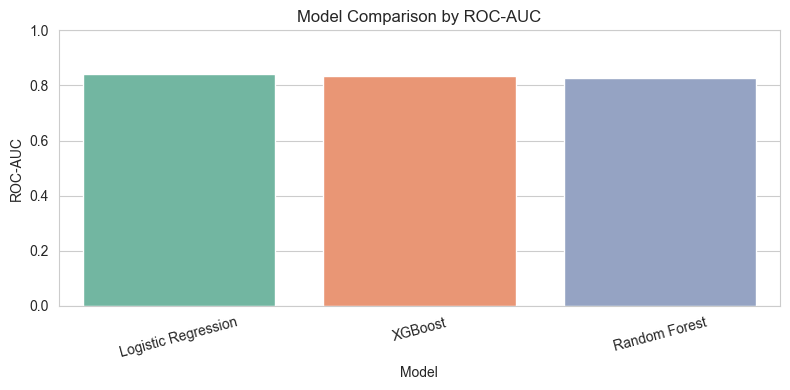

Best model by ROC-AUC: Logistic Regression


In [61]:
# Final step: Compare all ML models together
results_df = pd.DataFrame(model_results).sort_values(by="ROC_AUC", ascending=False).reset_index(drop=True)
display(results_df.round(4))

plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="Model", y="ROC_AUC", palette="Set2")
plt.title("Model Comparison by ROC-AUC")
plt.ylim(0, 1)
plt.ylabel("ROC-AUC")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print(f"Best model by ROC-AUC: {results_df.loc[0, 'Model']}")

In [62]:
from sklearn.metrics import accuracy_score, classification_report

if "xgb_model" not in globals():
    raise NameError("xgb_model is not available. Run the XGBoost training cell first.")

y_pred = xgb_model.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.7857651245551601
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1033
           1       0.62      0.48      0.54       372

    accuracy                           0.79      1405
   macro avg       0.73      0.69      0.70      1405
weighted avg       0.77      0.79      0.78      1405



In [63]:
# Step 1: Leakage-safe split (split first)
from sklearn.model_selection import train_test_split

if "df_raw" in globals():
    base_df = df_raw.copy()
elif "df" in globals():
    base_df = df.copy()
else:
    base_df = pd.read_csv("telco_churn_processed.csv")

if "Churn" not in base_df.columns:
    raise ValueError("Target column 'Churn' not found.")

y_raw = base_df["Churn"].astype(str).str.strip().str.lower().map({
    "yes": 1, "true": 1, "1": 1,
    "no": 0, "false": 0, "0": 0
})

valid_mask = y_raw.notna()
base_df = base_df.loc[valid_mask].copy()
y_raw = y_raw.loc[valid_mask].astype(int)
X_raw = base_df.drop(columns=["Churn"])

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_raw, y_raw,
    test_size=0.2,
    random_state=42,
    stratify=y_raw
)

print(f"Train shape: {X_train_raw.shape} | Test shape: {X_test_raw.shape}")
print(f"Train churn rate: {y_train_raw.mean():.4f} | Test churn rate: {y_test_raw.mean():.4f}")

Train shape: (5634, 30) | Test shape: (1409, 30)
Train churn rate: 0.2654 | Test churn rate: 0.2654


In [64]:
# Step 2: ColumnTransformer preprocessing + imbalance setup
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
bool_features = X_train_raw.select_dtypes(include=["bool", "boolean"]).columns.tolist()
numeric_features = [c for c in numeric_features if c not in bool_features]

categorical_features = X_train_raw.select_dtypes(exclude=[np.number]).columns.tolist()
categorical_features = [c for c in categorical_features if c not in bool_features]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

bool_transformer = Pipeline(steps=[
    ("to_object", FunctionTransformer(lambda x: x.astype("object"), validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
        ("bool", bool_transformer, bool_features),
    ]
)

neg_count = int((y_train_raw == 0).sum())
pos_count = int((y_train_raw == 1).sum())
scale_pos_weight = neg_count / max(pos_count, 1)

print(f"Numeric features: {len(numeric_features)} | Categorical features: {len(categorical_features)} | Bool features: {len(bool_features)}")
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.3f}")

Numeric features: 8 | Categorical features: 0 | Bool features: 22
scale_pos_weight for XGBoost: 2.769


In [68]:
# Step 3: Baseline CV with leakage-safe pipelines
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate

baseline_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=3000, class_weight="balanced", random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, class_weight="balanced_subsample", random_state=42, n_jobs=-1
    ),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision",
    "f1": "f1",
    "recall": "recall",
    "accuracy": "accuracy",
}

baseline_cv_rows = []
for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", model)])
    scores = cross_validate(pipe, X_train_raw, y_train_raw, cv=cv, scoring=scoring, n_jobs=-1)
    baseline_cv_rows.append({
        "Model": name,
        "CV_ROC_AUC": np.mean(scores["test_roc_auc"]),
        "CV_PR_AUC": np.mean(scores["test_pr_auc"]),
        "CV_F1": np.mean(scores["test_f1"]),
        "CV_Recall": np.mean(scores["test_recall"]),
        "CV_Accuracy": np.mean(scores["test_accuracy"]),
    })

baseline_cv_df = pd.DataFrame(baseline_cv_rows).sort_values("CV_ROC_AUC", ascending=False)
display(baseline_cv_df.round(4))

,Model,CV_ROC_AUC,CV_PR_AUC,CV_F1,CV_Recall,CV_Accuracy
0,Logistic Regression,0.846,0.6600,0.6286,0.8013,0.7488
1,Random Forest,0.822,0.6121,0.5452,0.4756,0.7895


In [69]:
# Step 4: Hyperparameter tuning (RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV

search_spaces = {
    "Logistic Regression": {
        "estimator": LogisticRegression(class_weight="balanced", random_state=42),
        "params": {
            "model__C": np.logspace(-3, 2, 25),
            "model__solver": ["lbfgs", "liblinear"],
        },
    },
    "Random Forest": {
        "estimator": RandomForestClassifier(class_weight="balanced_subsample", random_state=42, n_jobs=-1),
        "params": {
            "model__n_estimators": [200, 300, 400, 500],
            "model__max_depth": [None, 6, 8, 10, 14],
            "model__min_samples_split": [2, 4, 8, 12],
            "model__min_samples_leaf": [1, 2, 4, 6],
            "model__max_features": ["sqrt", "log2", None],
        },
    },
}

tuned_models = {}
tuned_cv_rows = []

for name, cfg in search_spaces.items():
    pipe = Pipeline(steps=[("prep", preprocessor), ("model", cfg["estimator"])])
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=cfg["params"],
        n_iter=20,
        scoring="roc_auc",
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train_raw, y_train_raw)
    tuned_models[name] = search.best_estimator_
    tuned_cv_rows.append({
        "Model": name,
        "Best_CV_ROC_AUC": search.best_score_,
        "Best_Params": search.best_params_,
    })

tuned_cv_df = pd.DataFrame(tuned_cv_rows).sort_values("Best_CV_ROC_AUC", ascending=False)
display(tuned_cv_df[["Model", "Best_CV_ROC_AUC"]].round(4))
print("Tuning completed.")

,Model,Best_CV_ROC_AUC
1,Random Forest,0.8464
0,Logistic Regression,0.8462


Tuning completed.


In [70]:
# Step 5: Threshold tuning on holdout test set
from sklearn.metrics import average_precision_score, f1_score, precision_recall_curve

threshold_rows = []
best_thresholds = {}
test_probabilities = {}

for name, model in tuned_models.items():
    proba = model.predict_proba(X_test_raw)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test_raw, proba)
    f1_scores = (2 * precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-12)

    if len(thresholds) == 0:
        best_thr = 0.5
    else:
        best_idx = int(np.nanargmax(f1_scores))
        best_thr = float(thresholds[best_idx])

    pred = (proba >= best_thr).astype(int)
    best_thresholds[name] = best_thr
    test_probabilities[name] = proba

    threshold_rows.append({
        "Model": name,
        "Threshold": best_thr,
        "ROC_AUC": roc_auc_score(y_test_raw, proba),
        "PR_AUC": average_precision_score(y_test_raw, proba),
        "F1": f1_score(y_test_raw, pred),
        "Recall": recall_score(y_test_raw, pred),
        "Precision": precision_score(y_test_raw, pred),
        "Accuracy": accuracy_score(y_test_raw, pred),
    })

threshold_df = pd.DataFrame(threshold_rows).sort_values("PR_AUC", ascending=False)
display(threshold_df.round(4))

,Model,Threshold,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy
1,Random Forest,0.4681,0.8424,0.6518,0.6380,0.7941,0.5332,0.7608
0,Logistic Regression,0.5684,0.8406,0.6269,0.6216,0.7380,0.5370,0.7615


,Model,Threshold,ROC_AUC,PR_AUC,F1,Recall,Precision,Accuracy
0,Random Forest,0.4681,0.8424,0.6518,0.6380,0.7941,0.5332,0.7608
1,Logistic Regression,0.5684,0.8406,0.6269,0.6216,0.7380,0.5370,0.7615


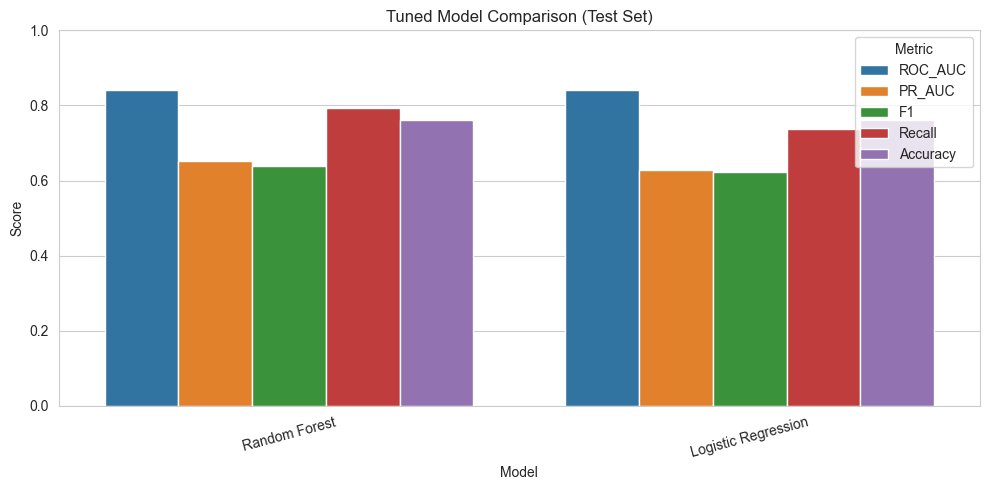

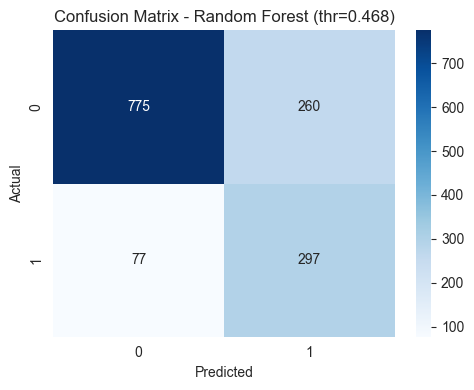

Best tuned model by PR-AUC: Random Forest
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1035
           1       0.53      0.79      0.64       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



In [71]:
# Step 6: Final model comparison + confusion matrix/report
from sklearn.metrics import classification_report, confusion_matrix

final_compare_df = threshold_df.sort_values("PR_AUC", ascending=False).reset_index(drop=True)
display(final_compare_df.round(4))

plot_df = final_compare_df.melt(
    id_vars="Model",
    value_vars=["ROC_AUC", "PR_AUC", "F1", "Recall", "Accuracy"],
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="Score", hue="Metric")
plt.title("Tuned Model Comparison (Test Set)")
plt.ylim(0, 1)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

best_model_name = final_compare_df.loc[0, "Model"]
best_model = tuned_models[best_model_name]
best_thr = best_thresholds[best_model_name]
best_pred = (test_probabilities[best_model_name] >= best_thr).astype(int)

cm = confusion_matrix(y_test_raw, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name} (thr={best_thr:.3f})")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"Best tuned model by PR-AUC: {best_model_name}")
print(classification_report(y_test_raw, best_pred))

In [72]:
# Unsupervised clustering prep (feature matrix without target)
from scipy import sparse
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

if "df_raw" in globals():
    clustering_df = df_raw.copy()
elif "df" in globals():
    clustering_df = df.copy()
else:
    clustering_df = pd.read_csv("telco_churn_processed.csv")

drop_cols = [c for c in ["Churn", "customerID"] if c in clustering_df.columns]
X_cluster_df = clustering_df.drop(columns=drop_cols).copy()

num_cols = X_cluster_df.select_dtypes(include=[np.number]).columns.tolist()
bool_cols = X_cluster_df.select_dtypes(include=["bool", "boolean"]).columns.tolist()
num_cols = [c for c in num_cols if c not in bool_cols]
cat_cols = X_cluster_df.select_dtypes(exclude=[np.number]).columns.tolist()
cat_cols = [c for c in cat_cols if c not in bool_cols]

num_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])
cat_pipe = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])
bool_pipe = Pipeline(steps=[
    ("to_object", FunctionTransformer(lambda x: x.astype("object"), validate=False)),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

cluster_prep = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_cols),
        ("cat", cat_pipe, cat_cols),
        ("bool", bool_pipe, bool_cols),
    ]
)

X_cluster = cluster_prep.fit_transform(X_cluster_df)

if sparse.issparse(X_cluster):
    n_components = min(30, max(2, X_cluster.shape[1] - 1))
    reducer = TruncatedSVD(n_components=n_components, random_state=42)
    X_cluster_reduced = reducer.fit_transform(X_cluster)
else:
    X_dense = np.asarray(X_cluster)
    n_components = min(30, X_dense.shape[1], max(2, X_dense.shape[0] - 1))
    reducer = PCA(n_components=n_components, random_state=42)
    X_cluster_reduced = reducer.fit_transform(X_dense)

viz_pca = PCA(n_components=2, random_state=42)
X_cluster_2d = viz_pca.fit_transform(X_cluster_reduced)

cluster_results = []
print(f"Clustering matrix shape: {X_cluster_reduced.shape}")

Clustering matrix shape: (7043, 30)


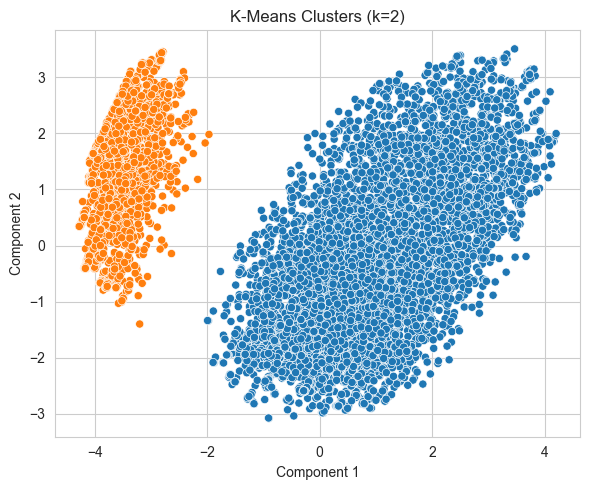

K-Means best k: 2 | Silhouette: 0.2578


In [73]:
# K-Means clustering
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score

k_values = list(range(2, 9))
k_sil_scores = []

for k in k_values:
    km_tmp = KMeans(n_clusters=k, n_init=20, random_state=42)
    labels_tmp = km_tmp.fit_predict(X_cluster_reduced)
    k_sil_scores.append(silhouette_score(X_cluster_reduced, labels_tmp))

best_k = k_values[int(np.argmax(k_sil_scores))]
kmeans_model = KMeans(n_clusters=best_k, n_init=30, random_state=42)
kmeans_labels = kmeans_model.fit_predict(X_cluster_reduced)

kmeans_sil = silhouette_score(X_cluster_reduced, kmeans_labels)
kmeans_dbi = davies_bouldin_score(X_cluster_reduced, kmeans_labels)

cluster_results.append({
    "Model": "KMeans",
    "Clusters": int(best_k),
    "Silhouette": float(kmeans_sil),
    "DaviesBouldin": float(kmeans_dbi),
    "NoisePoints": 0
})

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_cluster_2d[:, 0], y=X_cluster_2d[:, 1], hue=kmeans_labels, palette="tab10", s=35, legend=False)
plt.title(f"K-Means Clusters (k={best_k})")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()
print(f"K-Means best k: {best_k} | Silhouette: {kmeans_sil:.4f}")

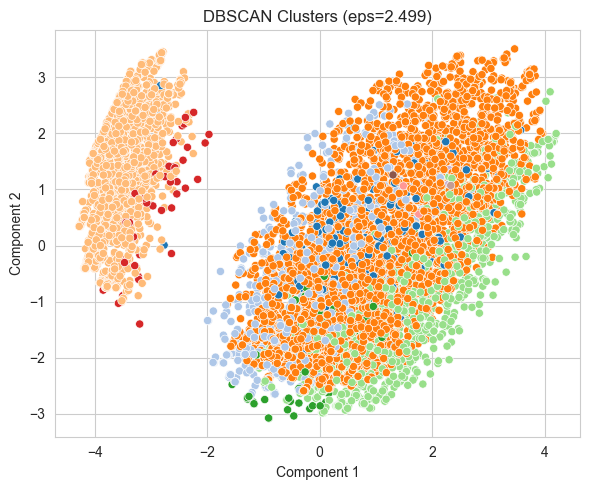

DBSCAN clusters: 11 | noise points: 211


In [74]:
# DBSCAN clustering
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

knn = NearestNeighbors(n_neighbors=5)
knn.fit(X_cluster_reduced)
distances, _ = knn.kneighbors(X_cluster_reduced)
eps_guess = float(np.percentile(distances[:, -1], 90))

dbscan_model = DBSCAN(eps=eps_guess, min_samples=5, n_jobs=-1)
dbscan_labels = dbscan_model.fit_predict(X_cluster_reduced)

dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
noise_points = int(np.sum(dbscan_labels == -1))

if dbscan_clusters > 1:
    non_noise_mask = dbscan_labels != -1
    if np.sum(non_noise_mask) > 10 and len(np.unique(dbscan_labels[non_noise_mask])) > 1:
        dbscan_sil = silhouette_score(X_cluster_reduced[non_noise_mask], dbscan_labels[non_noise_mask])
        dbscan_dbi = davies_bouldin_score(X_cluster_reduced[non_noise_mask], dbscan_labels[non_noise_mask])
    else:
        dbscan_sil = np.nan
        dbscan_dbi = np.nan
else:
    dbscan_sil = np.nan
    dbscan_dbi = np.nan

cluster_results.append({
    "Model": "DBSCAN",
    "Clusters": int(max(dbscan_clusters, 0)),
    "Silhouette": float(dbscan_sil) if not np.isnan(dbscan_sil) else np.nan,
    "DaviesBouldin": float(dbscan_dbi) if not np.isnan(dbscan_dbi) else np.nan,
    "NoisePoints": noise_points
})

plot_labels = dbscan_labels.copy()
plt.figure(figsize=(6, 5))
sns.scatterplot(
    x=X_cluster_2d[:, 0],
    y=X_cluster_2d[:, 1],
    hue=plot_labels,
    palette="tab20",
    s=35,
    legend=False
)
plt.title(f"DBSCAN Clusters (eps={eps_guess:.3f})")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()
print(f"DBSCAN clusters: {dbscan_clusters} | noise points: {noise_points}")

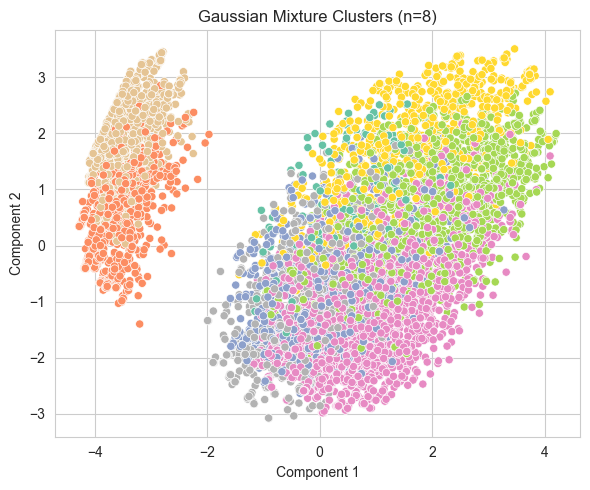

,Model,Clusters,Silhouette,DaviesBouldin,NoisePoints
0,KMeans,2,0.2578,1.3219,0
1,DBSCAN,11,0.0222,1.6035,211
2,GaussianMixture,8,0.1141,2.3871,0


Clustering completed: K-Means, DBSCAN, and Gaussian Mixture.


In [75]:
# Gaussian Mixture Model clustering + summary
from sklearn.mixture import GaussianMixture

gmm_candidates = list(range(2, 9))
gmm_bic_scores = []

for n_comp in gmm_candidates:
    gmm_tmp = GaussianMixture(n_components=n_comp, covariance_type="full", random_state=42)
    gmm_tmp.fit(X_cluster_reduced)
    gmm_bic_scores.append(gmm_tmp.bic(X_cluster_reduced))

best_gmm_n = gmm_candidates[int(np.argmin(gmm_bic_scores))]
gmm_model = GaussianMixture(n_components=best_gmm_n, covariance_type="full", random_state=42)
gmm_labels = gmm_model.fit_predict(X_cluster_reduced)

gmm_sil = silhouette_score(X_cluster_reduced, gmm_labels)
gmm_dbi = davies_bouldin_score(X_cluster_reduced, gmm_labels)

cluster_results.append({
    "Model": "GaussianMixture",
    "Clusters": int(best_gmm_n),
    "Silhouette": float(gmm_sil),
    "DaviesBouldin": float(gmm_dbi),
    "NoisePoints": 0
})

plt.figure(figsize=(6, 5))
sns.scatterplot(x=X_cluster_2d[:, 0], y=X_cluster_2d[:, 1], hue=gmm_labels, palette="Set2", s=35, legend=False)
plt.title(f"Gaussian Mixture Clusters (n={best_gmm_n})")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.tight_layout()
plt.show()

cluster_results_df = pd.DataFrame(cluster_results)
display(cluster_results_df.round(4))
print("Clustering completed: K-Means, DBSCAN, and Gaussian Mixture.")

In [76]:
# Compare the three clustering methods and pick the best
if "cluster_results_df" not in globals():
    cluster_results_df = pd.DataFrame(cluster_results)

compare_df = cluster_results_df.copy()

# Safe numeric conversion
for c in ["Silhouette", "DaviesBouldin", "NoisePoints"]:
    compare_df[c] = pd.to_numeric(compare_df[c], errors="coerce")

# Fill missing metrics (e.g., DBSCAN can be NaN when only one cluster is found)
sil_filled = compare_df["Silhouette"].fillna(compare_df["Silhouette"].min())
dbi_filled = compare_df["DaviesBouldin"].fillna(compare_df["DaviesBouldin"].max())
noise_filled = compare_df["NoisePoints"].fillna(compare_df["NoisePoints"].max())

def minmax_scale(s):
    s_min, s_max = s.min(), s.max()
    if pd.isna(s_min) or pd.isna(s_max) or s_max == s_min:
        return pd.Series(np.ones(len(s)), index=s.index)
    return (s - s_min) / (s_max - s_min)

sil_score = minmax_scale(sil_filled)                 # higher is better
dbi_score = 1 - minmax_scale(dbi_filled)             # lower is better
noise_score = 1 - minmax_scale(noise_filled)         # lower is better

compare_df["FinalScore"] = 0.5 * sil_score + 0.3 * dbi_score + 0.2 * noise_score
compare_df = compare_df.sort_values("FinalScore", ascending=False).reset_index(drop=True)

display(compare_df.round(4))
print(f"Best clustering method: {compare_df.loc[0, 'Model']}")

,Model,Clusters,Silhouette,DaviesBouldin,NoisePoints,FinalScore
0,KMeans,2,0.2578,1.3219,0,1.0000
1,GaussianMixture,8,0.1141,2.3871,0,0.3950
2,DBSCAN,11,0.0222,1.6035,211,0.2207


Best clustering method: KMeans


In [77]:
# Survival Analysis Step 1: Prepare data for Cox PH
if "df_raw" in globals():
    surv_df = df_raw.copy()
elif "df" in globals():
    surv_df = df.copy()
else:
    surv_df = pd.read_csv("telco_churn_processed.csv")

required_cols = ["tenure", "Churn"]
missing_required = [c for c in required_cols if c not in surv_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns for survival analysis: {missing_required}")

# Duration (time to event)
surv_df["tenure"] = pd.to_numeric(surv_df["tenure"], errors="coerce")

# Event flag: 1 = churn happened, 0 = censored
surv_df["event"] = surv_df["Churn"].astype(str).str.strip().str.lower().map({
    "yes": 1, "true": 1, "1": 1,
    "no": 0, "false": 0, "0": 0
})

# Keep valid rows only
surv_df = surv_df.dropna(subset=["tenure", "event"]).copy()
surv_df = surv_df[surv_df["tenure"] > 0].copy()
surv_df["event"] = surv_df["event"].astype(int)

# Remove identifier/target leakage columns and keep tenure/event out of covariates
drop_cols = [c for c in ["customerID", "Churn", "tenure", "event"] if c in surv_df.columns]
X_surv = surv_df.drop(columns=drop_cols).copy()

# Encode categorical features for Cox PH
cat_cols = X_surv.select_dtypes(include=["object", "category", "bool", "boolean"]).columns.tolist()
if cat_cols:
    X_surv = pd.get_dummies(X_surv, columns=cat_cols, drop_first=True, dtype=float)

# Final Cox dataset
cox_df = pd.concat([X_surv, surv_df[["tenure", "event"]]], axis=1)
cox_df = cox_df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"Cox dataset shape: {cox_df.shape}")
print(f"Event rate: {cox_df['event'].mean():.4f}")

Cox dataset shape: (3268, 31)
Event rate: 0.1252


Cox PH Concordance Index (test): 0.8769
Top 10 features increasing churn hazard (hazard_ratio > 1):


,coef,hazard_ratio,p_value
covariate,,,
InternetService_Fiber optic_True,0.4762,1.6099,0.0000
PaymentMethod_Electronic check_True,0.4134,1.5119,0.0000
StreamingTV_Yes_True,0.1758,1.1922,0.0563
StreamingMovies_Yes_True,0.1218,1.1295,0.1850
MonthlyCharges,0.1129,1.1195,0.0397
PaperlessBilling,0.1128,1.1194,0.0129
MultipleLines_Yes_True,0.1107,1.1171,0.2420
gender_Male_True,0.0491,1.0503,0.5525
SeniorCitizen,0.0451,1.0461,0.2280


Top 10 features reducing churn hazard (hazard_ratio < 1):


,coef,hazard_ratio,p_value
covariate,,,
Contract_Two year_True,-0.8345,0.4341,0.0000
TotalCharges,-0.4285,0.6515,0.0000
OnlineSecurity_Yes_True,-0.3448,0.7083,0.0001
Contract_One year_True,-0.2554,0.7746,0.0056
TechSupport_Yes_True,-0.2458,0.7821,0.0054
TechSupport_No internet service_True,-0.2308,0.7939,0.1125
StreamingMovies_No internet service_True,-0.2308,0.7939,0.1125
InternetService_No_True,-0.2308,0.7939,0.1125
StreamingTV_No internet service_True,-0.2308,0.7939,0.1125


C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\4076339254.py:64: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_effects["coef"].values, y=top_effects.index, palette="coolwarm")


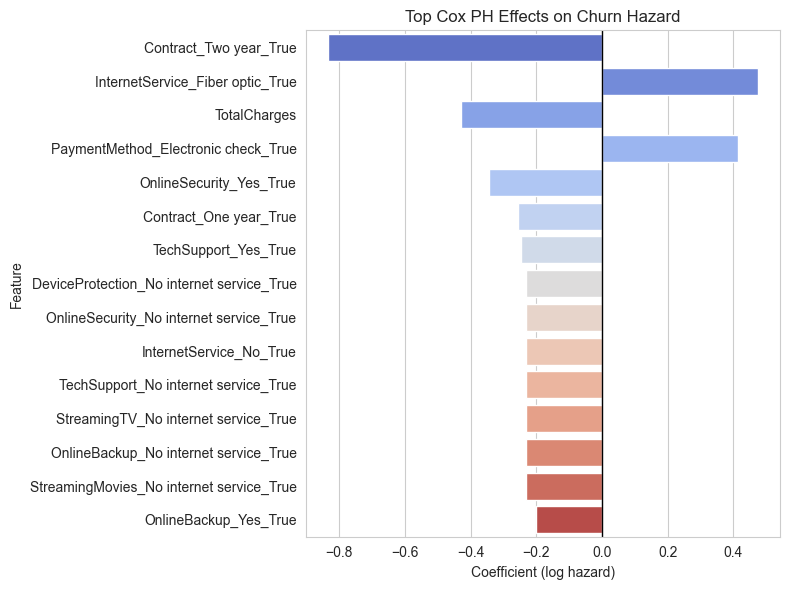

In [78]:
# Survival Analysis Step 2: Fit Cox PH and interpret hazard ratios
try:
    from lifelines import CoxPHFitter
except ImportError:
    raise ImportError("Package 'lifelines' is required. Install it with: pip install lifelines")

from sklearn.model_selection import train_test_split

# Build cox_df on the fly if Step 1 was not run
if "cox_df" not in globals():
    if "df_raw" in globals():
        surv_df = df_raw.copy()
    elif "df" in globals():
        surv_df = df.copy()
    else:
        surv_df = pd.read_csv("telco_churn_processed.csv")

    if "tenure" not in surv_df.columns or "Churn" not in surv_df.columns:
        raise ValueError("Columns 'tenure' and 'Churn' are required for Cox PH.")

    surv_df["tenure"] = pd.to_numeric(surv_df["tenure"], errors="coerce")
    surv_df["event"] = surv_df["Churn"].astype(str).str.strip().str.lower().map({
        "yes": 1, "true": 1, "1": 1,
        "no": 0, "false": 0, "0": 0
    })
    surv_df = surv_df.dropna(subset=["tenure", "event"]).copy()
    surv_df = surv_df[surv_df["tenure"] > 0].copy()
    surv_df["event"] = surv_df["event"].astype(int)

    drop_cols = [c for c in ["customerID", "Churn", "tenure", "event"] if c in surv_df.columns]
    X_surv = surv_df.drop(columns=drop_cols).copy()
    cat_cols = X_surv.select_dtypes(include=["object", "category", "bool", "boolean"]).columns.tolist()
    if cat_cols:
        X_surv = pd.get_dummies(X_surv, columns=cat_cols, drop_first=True, dtype=float)

    cox_df = pd.concat([X_surv, surv_df[["tenure", "event"]]], axis=1)
    cox_df = cox_df.replace([np.inf, -np.inf], np.nan).dropna()

train_cox, test_cox = train_test_split(
    cox_df, test_size=0.2, random_state=42, stratify=cox_df["event"]
)

coxph = CoxPHFitter(penalizer=0.1)
coxph.fit(train_cox, duration_col="tenure", event_col="event")

# Concordance index on holdout set
c_index = coxph.score(test_cox, scoring_method="concordance_index")
print(f"Cox PH Concordance Index (test): {c_index:.4f}")

# Hazard ratio summary
hr_df = coxph.summary[["coef", "exp(coef)", "p"]].copy()
hr_df = hr_df.rename(columns={"exp(coef)": "hazard_ratio", "p": "p_value"})
hr_df = hr_df.sort_values("hazard_ratio", ascending=False)

print("Top 10 features increasing churn hazard (hazard_ratio > 1):")
display(hr_df.head(10).round(4))

print("Top 10 features reducing churn hazard (hazard_ratio < 1):")
display(hr_df.tail(10).sort_values("hazard_ratio", ascending=True).round(4))

# Optional: visualize strongest effects by absolute coefficient
top_effects = hr_df.reindex(hr_df["coef"].abs().sort_values(ascending=False).head(15).index)
plt.figure(figsize=(8, 6))
sns.barplot(x=top_effects["coef"].values, y=top_effects.index, palette="coolwarm")
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Cox PH Effects on Churn Hazard")
plt.xlabel("Coefficient (log hazard)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [79]:
# LSTM/GRU Step 1: Build pseudo time-series from tenure bins
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score

# Auto-install TensorFlow in-kernel if missing
try:
    import tensorflow as tf
except ImportError:
    import sys
    import subprocess
    print("TensorFlow not found. Installing tensorflow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"] )
    import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, LSTM, GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

if "df_raw" in globals():
    seq_df = df_raw.copy()
elif "df" in globals():
    seq_df = df.copy()
else:
    seq_df = pd.read_csv("telco_churn_processed.csv")

required_cols = ["tenure", "Churn", "MonthlyCharges", "TotalCharges"]
missing_cols = [c for c in required_cols if c not in seq_df.columns]
if missing_cols:
    raise ValueError(f"Missing required columns for LSTM/GRU pipeline: {missing_cols}")

seq_df["tenure"] = pd.to_numeric(seq_df["tenure"], errors="coerce")
seq_df["MonthlyCharges"] = pd.to_numeric(seq_df["MonthlyCharges"], errors="coerce")
seq_df["TotalCharges"] = pd.to_numeric(seq_df["TotalCharges"], errors="coerce")
seq_df["ChurnBin"] = seq_df["Churn"].astype(str).str.strip().str.lower().map({
    "yes": 1, "true": 1, "1": 1,
    "no": 0, "false": 0, "0": 0
})

seq_df = seq_df.dropna(subset=["tenure", "MonthlyCharges", "TotalCharges", "ChurnBin"]).copy()
seq_df = seq_df[seq_df["tenure"] > 0].copy()
seq_df["ChurnBin"] = seq_df["ChurnBin"].astype(int)

seq_len = 8
tenure_max = float(seq_df["tenure"].max())
bin_ends = np.linspace(tenure_max / seq_len, tenure_max, seq_len)

monthly_mean = float(seq_df["MonthlyCharges"].mean())
monthly_std = float(seq_df["MonthlyCharges"].std() + 1e-8)
total_scale = float(seq_df["TotalCharges"].max() + 1e-8)

def build_customer_sequence(row):
    tenure = float(row["tenure"] )
    monthly = float(row["MonthlyCharges"] )
    total = float(row["TotalCharges"] )
    seq = []
    for end_t in bin_ends:
        active = 1.0 if tenure >= end_t else 0.0
        tenure_progress = min(tenure / end_t, 1.0) if end_t > 0 else 0.0
        monthly_z = (monthly - monthly_mean) / monthly_std
        spend_t = min(total, monthly * end_t) / total_scale
        recency_proxy = max(0.0, (end_t - tenure) / tenure_max) if tenure_max > 0 else 0.0
        seq.append([active, tenure_progress, monthly_z, spend_t, recency_proxy])
    return np.array(seq, dtype=np.float32)

X_seq = np.stack(seq_df.apply(build_customer_sequence, axis=1).values)
y_seq = seq_df["ChurnBin"].values.astype(np.float32)

X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

n_pos = max(1, int((y_train_seq == 1).sum()))
n_neg = max(1, int((y_train_seq == 0).sum()))
class_weight = {0: 1.0, 1: n_neg / n_pos}

print(f"Pseudo sequence tensor shape: {X_seq.shape}")
print(f"Train shape: {X_train_seq.shape} | Test shape: {X_test_seq.shape}")
print(f"Positive class weight: {class_weight[1]:.3f}")

Pseudo sequence tensor shape: (3268, 8, 5)
Train shape: (2614, 8, 5) | Test shape: (654, 8, 5)
Positive class weight: 6.994


In [80]:
# LSTM/GRU Step 2: Train LSTM and GRU models
tf.keras.utils.set_random_seed(42)

def build_lstm_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_gru_model(input_shape):
    model = Sequential([
        Input(shape=input_shape),
        GRU(64, return_sequences=True),
        Dropout(0.2),
        GRU(32),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)
input_shape = (X_train_seq.shape[1], X_train_seq.shape[2])

lstm_model = build_lstm_model(input_shape)
gru_model = build_gru_model(input_shape)

lstm_history = lstm_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=0
)

gru_history = gru_model.fit(
    X_train_seq, y_train_seq,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    callbacks=[early_stop],
    class_weight=class_weight,
    verbose=0
)

def evaluate_seq_model(model, X_test, y_test, name):
    prob = model.predict(X_test, verbose=0).ravel()
    pred = (prob >= 0.5).astype(int)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, prob),
        "PR_AUC": average_precision_score(y_test, prob),
    }

seq_results = [
    evaluate_seq_model(lstm_model, X_test_seq, y_test_seq, "LSTM (Pseudo Time-Series)"),
    evaluate_seq_model(gru_model, X_test_seq, y_test_seq, "GRU (Pseudo Time-Series)"),
]

seq_results_df = pd.DataFrame(seq_results).sort_values("PR_AUC", ascending=False).reset_index(drop=True)
display(seq_results_df.round(4))

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,GRU (Pseudo Time-Series),0.6820,0.2397,0.7073,0.3580,0.7459,0.2514
1,LSTM (Pseudo Time-Series),0.6758,0.2246,0.6463,0.3333,0.7392,0.2426


C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\4215501125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seq_results_df, x="Model", y="PR_AUC", palette="Set2")


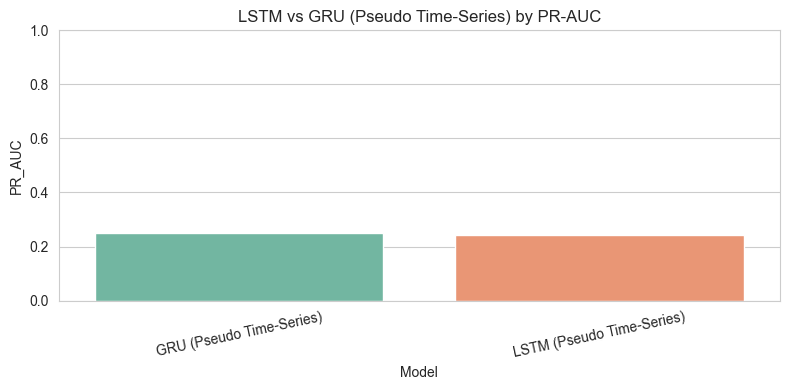

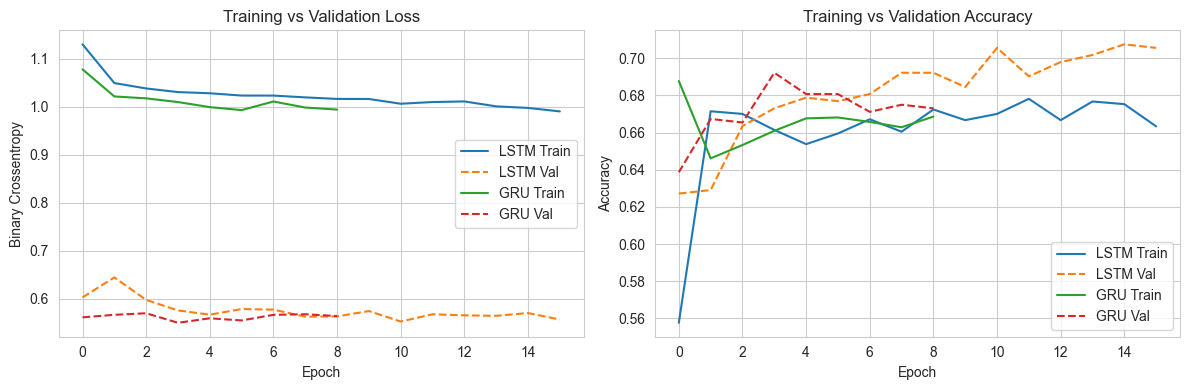

Best sequential model by PR-AUC: GRU (Pseudo Time-Series)


In [81]:
# LSTM/GRU Step 3: Compare sequential models and visualize training
plt.figure(figsize=(8, 4))
sns.barplot(data=seq_results_df, x="Model", y="PR_AUC", palette="Set2")
plt.title("LSTM vs GRU (Pseudo Time-Series) by PR-AUC")
plt.ylim(0, 1)
plt.xticks(rotation=12)
plt.tight_layout()
plt.show()

histories = {
    "LSTM": lstm_history.history,
    "GRU": gru_history.history,
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, hist in histories.items():
    axes[0].plot(hist["loss"], label=f"{name} Train")
    axes[0].plot(hist["val_loss"], linestyle="--", label=f"{name} Val")
    axes[1].plot(hist["accuracy"], label=f"{name} Train")
    axes[1].plot(hist["val_accuracy"], linestyle="--", label=f"{name} Val")

axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Binary Crossentropy")
axes[0].legend()

axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Best sequential model by PR-AUC: {seq_results_df.loc[0, 'Model']}")

In [82]:
# SHAP Step 1: Build explainer from trained churn model (XGBoost/RF)
import numpy as np
import pandas as pd

# Install SHAP if missing
try:
    import shap
except ImportError:
    import sys
    import subprocess
    print("SHAP not found. Installing shap...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap

# -------------------------------
# Select model (XGBoost or RF)
# -------------------------------
if "xgb_model" in globals() and "X_test" in globals():
    shap_model = xgb_model
    X_explain = X_test.copy()
    model_name = "XGBoost"

elif "rf_model" in globals() and "X_test" in globals():
    shap_model = rf_model
    X_explain = X_test.copy()
    model_name = "Random Forest"

else:
    raise ValueError(
        "No compatible trained XGBoost/RF model found. Run training first."
    )

# -------------------------------
# Reduce sample size (faster SHAP)
# -------------------------------
n_explain = min(300, len(X_explain))
X_explain_sample = X_explain.head(n_explain).copy()

# -------------------------------
# ✅ FIX: Use callable model
# -------------------------------
explainer = shap.Explainer(shap_model.predict_proba, X_explain_sample)
shap_values = explainer(X_explain_sample)

# -------------------------------
# Select class 1 (churn)
# -------------------------------
shap_values_class1 = shap_values[:, :, 1]

# -------------------------------
# Output info
# -------------------------------
print(f"SHAP ready for model: {model_name}")
print(f"SHAP values shape: {shap_values_class1.values.shape}")
print(f"Explain sample shape: {X_explain_sample.shape}")

PermutationExplainer explainer: 301it [00:34,  5.85it/s]                         

SHAP ready for model: XGBoost
SHAP values shape: (300, 37)
Explain sample shape: (300, 37)


Top global churn drivers by SHAP:


,Feature,MeanAbsSHAP
0,tenure,0.051248
1,Contract_Two year,0.046952
2,InternetService_Fiber optic,0.045913
3,Contract_One year,0.039459
4,TotalCharges,0.028977
5,MonthlyCharges,0.025747
6,AvgMonthlyValue,0.021459
7,PaperlessBilling,0.020305
8,CLV,0.019898
9,PaymentMethod_Electronic check,0.017708


Customer row: 0
Predicted churn probability: 0.6562
Top feature-level reasons for this customer:


,Feature,FeatureValue,SHAPValue,AbsSHAP
0,InternetService_Fiber optic,1.000000,0.081725,0.081725
1,Contract_One year,0.000000,0.060479,0.060479
2,tenure,-1.038162,0.058689,0.058689
3,Contract_Two year,0.000000,0.048911,0.048911
4,SeniorCitizen,2.273159,0.038081,0.038081
5,CLV,-0.345219,-0.038027,0.038027
6,MultipleLines_Yes,1.000000,0.035738,0.035738
7,PaperlessBilling,0.829798,0.034093,0.034093
8,PaymentMethod_Electronic check,1.000000,0.024524,0.024524
9,TechSupport_Yes,0.000000,0.022420,0.022420


Force plot could not be rendered: 'PermutationExplainer' object has no attribute 'expected_value'


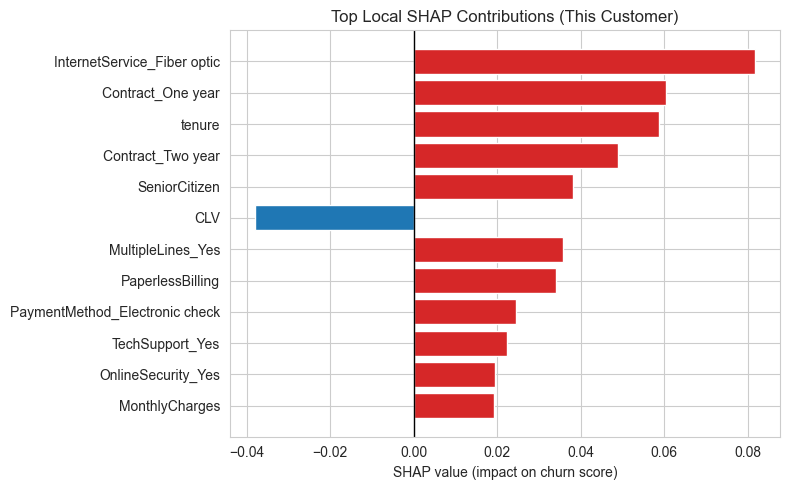

In [83]:
# SHAP Step 2: Per-customer explanation (WHY predicted churn)
import matplotlib.pyplot as plt

# Use class-1 SHAP values when available (binary churn explanation)
if "shap_values_class1" in globals():
    shap_exp = shap_values_class1
else:
    shap_exp = shap_values

# Convert SHAP explanation to a numeric matrix
if hasattr(shap_exp, "values"):
    shap_matrix = np.asarray(shap_exp.values)
else:
    shap_matrix = np.asarray(shap_exp)

# Handle possible extra dimensions robustly
if shap_matrix.ndim == 3 and shap_matrix.shape[-1] >= 2:
    shap_matrix = shap_matrix[:, :, 1]
elif shap_matrix.ndim > 2:
    shap_matrix = np.squeeze(shap_matrix)

if shap_matrix.ndim != 2:
    raise ValueError(f"Unexpected SHAP matrix shape: {shap_matrix.shape}")

# Global importance summary
mean_abs_shap = np.abs(shap_matrix).mean(axis=0)
global_importance_df = pd.DataFrame({
    "Feature": X_explain_sample.columns,
    "MeanAbsSHAP": mean_abs_shap
}).sort_values("MeanAbsSHAP", ascending=False).reset_index(drop=True)

print("Top global churn drivers by SHAP:")
display(global_importance_df.head(15))

# Choose a customer row from the explain sample
customer_row = 0  # change this index to explain another customer
customer_features = X_explain_sample.iloc[customer_row]
customer_shap = shap_matrix[customer_row]

# Predicted churn probability
customer_proba = float(shap_model.predict_proba(X_explain_sample.iloc[[customer_row]])[:, 1][0])
print(f"Customer row: {customer_row}")
print(f"Predicted churn probability: {customer_proba:.4f}")

# Per-feature contribution table (positive -> increases churn risk)
customer_explain_df = pd.DataFrame({
    "Feature": X_explain_sample.columns,
    "FeatureValue": customer_features.values,
    "SHAPValue": customer_shap
})
customer_explain_df["AbsSHAP"] = customer_explain_df["SHAPValue"].abs()
customer_explain_df = customer_explain_df.sort_values("AbsSHAP", ascending=False).reset_index(drop=True)

print("Top feature-level reasons for this customer:")
display(customer_explain_df.head(15))

# Force plot (matplotlib fallback for notebooks)
try:
    expected_value = explainer.expected_value
    expected_arr = np.atleast_1d(expected_value)
    if expected_arr.size >= 2:
        expected_value = float(expected_arr[1])
    else:
        expected_value = float(expected_arr[0])

    shap.force_plot(
        expected_value,
        customer_shap,
        customer_features,
        matplotlib=True,
        show=True
    )
except Exception as e:
    print(f"Force plot could not be rendered: {e}")

# Compact bar chart of top local drivers
top_local = customer_explain_df.head(12).copy()
plt.figure(figsize=(8, 5))
colors = ["#d62728" if v > 0 else "#1f77b4" for v in top_local["SHAPValue"]]
plt.barh(top_local["Feature"], top_local["SHAPValue"], color=colors)
plt.gca().invert_yaxis()
plt.axvline(0, color="black", linewidth=1)
plt.title("Top Local SHAP Contributions (This Customer)")
plt.xlabel("SHAP value (impact on churn score)")
plt.tight_layout()
plt.show()

In [84]:
# VAE Step 1: Prepare unsupervised feature matrix (target-free)
from sklearn.preprocessing import StandardScaler

if "df_raw" in globals():
    vae_df = df_raw.copy()
elif "df" in globals():
    vae_df = df.copy()
else:
    vae_df = pd.read_csv("telco_churn_processed.csv")

customer_id_series = vae_df["customerID"].copy() if "customerID" in vae_df.columns else pd.Series(vae_df.index, index=vae_df.index, name="customerID")

# Use behavioral features only (exclude ID/target)
drop_cols = [c for c in ["customerID", "Churn"] if c in vae_df.columns]
X_vae_df = vae_df.drop(columns=drop_cols).copy()

# Numeric conversion and one-hot encode for full feature matrix
for col in X_vae_df.columns:
    if X_vae_df[col].dtype == "object":
        try:
            X_vae_df[col] = pd.to_numeric(X_vae_df[col])
        except Exception:
            pass

cat_cols = X_vae_df.select_dtypes(include=["object", "category", "bool", "boolean"]).columns.tolist()
if cat_cols:
    X_vae_df = pd.get_dummies(X_vae_df, columns=cat_cols, drop_first=True, dtype=float)

# Final cleanup
X_vae_df = X_vae_df.replace([np.inf, -np.inf], np.nan).fillna(X_vae_df.median(numeric_only=True))
X_vae_df = X_vae_df.astype(float)

# Keep 31 features when available (as requested)
if X_vae_df.shape[1] >= 31:
    feature_variance = X_vae_df.var().sort_values(ascending=False)
    vae_feature_cols = feature_variance.head(31).index.tolist()
    X_vae_df = X_vae_df[vae_feature_cols].copy()
else:
    vae_feature_cols = X_vae_df.columns.tolist()

vae_scaler = StandardScaler()
X_vae_scaled = vae_scaler.fit_transform(X_vae_df).astype("float32")

n_vae = X_vae_scaled.shape[0]
val_size = max(1, int(0.2 * n_vae))
X_vae_train = X_vae_scaled[:-val_size] if n_vae > 5 else X_vae_scaled
X_vae_val = X_vae_scaled[-val_size:] if n_vae > 5 else X_vae_scaled

print(f"VAE feature count: {X_vae_scaled.shape[1]}")
print(f"VAE matrix shape: {X_vae_scaled.shape}")
print(f"Train/Val shapes: {X_vae_train.shape} / {X_vae_val.shape}")

VAE feature count: 30
VAE matrix shape: (7043, 30)
Train/Val shapes: (5635, 30) / (1408, 30)


VAE risk threshold (95th percentile): 0.224711
High-risk customers: 353 / 7043
Top anomaly-risk customers by reconstruction error:


,customerID,ReconstructionError,RiskLabel
0,6456,0.481978,HighRisk
1,6754,0.434055,HighRisk
2,3993,0.403800,HighRisk
3,296,0.396298,HighRisk
4,5660,0.391516,HighRisk
5,4933,0.384026,HighRisk
6,1029,0.381813,HighRisk
7,4416,0.378738,HighRisk
8,4913,0.378454,HighRisk
9,5366,0.375831,HighRisk


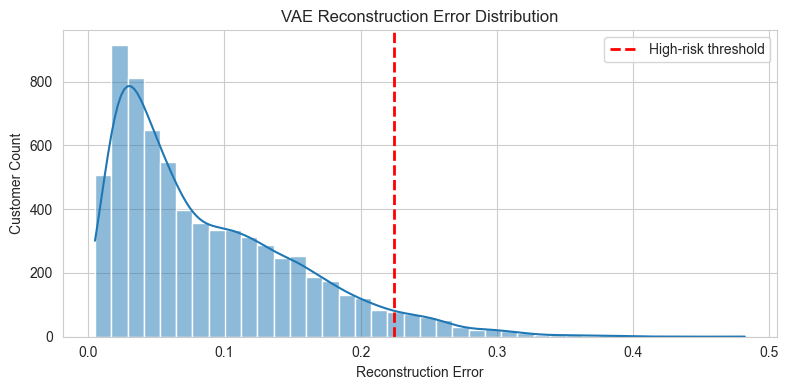

In [85]:
# VAE Step 2: Train variational autoencoder and compute reconstruction error per customer
try:
    import tensorflow as tf
except ImportError:
    import sys
    import subprocess
    print("TensorFlow not found. Installing tensorflow...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tensorflow", "-q"] )
    import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping

tf.keras.utils.set_random_seed(42)

input_dim = X_vae_scaled.shape[1]
latent_dim = 8 if input_dim >= 16 else max(2, input_dim // 2)
beta = 0.1

# Encoder network
encoder_inputs = keras.Input(shape=(input_dim,), name="encoder_input")
x = layers.Dense(64, activation="relu")(encoder_inputs)
x = layers.Dense(32, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)

def sampling(args):
    z_m, z_lv = args
    epsilon = tf.random.normal(shape=tf.shape(z_m))
    return z_m + tf.exp(0.5 * z_lv) * epsilon

z = layers.Lambda(sampling, name="z")([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")

# Decoder network
latent_inputs = keras.Input(shape=(latent_dim,), name="z_sampling")
d = layers.Dense(32, activation="relu")(latent_inputs)
d = layers.Dense(64, activation="relu")(d)
decoder_outputs = layers.Dense(input_dim, activation="linear")(d)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")

class VAE(keras.Model):
    def __init__(self, encoder_model, decoder_model, beta_weight=0.1, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder_model
        self.decoder = decoder_model
        self.beta = beta_weight

    def call(self, inputs):
        _, _, z_sample = self.encoder(inputs)
        return self.decoder(z_sample)

    def compute_losses(self, data):
        z_m, z_lv, z_sample = self.encoder(data, training=True)
        reconstruction = self.decoder(z_sample, training=True)
        recon_loss = tf.reduce_mean(tf.reduce_sum(tf.square(data - reconstruction), axis=1))
        kl_loss = -0.5 * tf.reduce_mean(tf.reduce_sum(1 + z_lv - tf.square(z_m) - tf.exp(z_lv), axis=1))
        total_loss = recon_loss + self.beta * kl_loss
        return total_loss, recon_loss, kl_loss

    def train_step(self, data):
        with tf.GradientTape() as tape:
            total_loss, recon_loss, kl_loss = self.compute_losses(data)
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

    def test_step(self, data):
        total_loss, recon_loss, kl_loss = self.compute_losses(data)
        return {"loss": total_loss, "recon_loss": recon_loss, "kl_loss": kl_loss}

vae_model = VAE(encoder, decoder, beta_weight=beta, name="vae_model")
vae_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3))

early_stop = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)

vae_history = vae_model.fit(
    X_vae_train,
    validation_data=(X_vae_val, None),
    epochs=80,
    batch_size=64,
    callbacks=[early_stop],
    verbose=0
)

X_vae_recon = vae_model.predict(X_vae_scaled, verbose=0)
reconstruction_error = np.mean(np.square(X_vae_scaled - X_vae_recon), axis=1)

risk_threshold = float(np.percentile(reconstruction_error, 95))
vae_results_df = pd.DataFrame({
    "customerID": customer_id_series.values,
    "ReconstructionError": reconstruction_error,
})
vae_results_df["RiskLabel"] = np.where(vae_results_df["ReconstructionError"] >= risk_threshold, "HighRisk", "Normal")
vae_results_df = vae_results_df.sort_values("ReconstructionError", ascending=False).reset_index(drop=True)

print(f"VAE risk threshold (95th percentile): {risk_threshold:.6f}")
print(f"High-risk customers: {(vae_results_df['RiskLabel'] == 'HighRisk').sum()} / {len(vae_results_df)}")

print("Top anomaly-risk customers by reconstruction error:")
display(vae_results_df.head(20))

plt.figure(figsize=(8, 4))
sns.histplot(vae_results_df["ReconstructionError"], bins=40, kde=True, color="#1f77b4")
plt.axvline(risk_threshold, color="red", linestyle="--", linewidth=2, label="High-risk threshold")
plt.title("VAE Reconstruction Error Distribution")
plt.xlabel("Reconstruction Error")
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()
plt.show()

In [86]:
# DoWhy Step 1: Prepare causal dataset (Contract, confounders, churn outcome)
try:
    import dowhy
    from dowhy import CausalModel
except ImportError:
    import sys
    import subprocess
    print("DoWhy not found. Installing dowhy...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "dowhy", "-q"] )
    from dowhy import CausalModel

if "df_raw" in globals():
    causal_base = df_raw.copy()
elif "df" in globals():
    causal_base = df.copy()
else:
    causal_base = pd.read_csv("telco_churn_processed.csv")

required_base_cols = ["tenure", "MonthlyCharges"]
missing_base_cols = [c for c in required_base_cols if c not in causal_base.columns]
if missing_base_cols:
    raise ValueError(f"Missing required numeric columns for DoWhy causal analysis: {missing_base_cols}")

if "Churn" not in causal_base.columns and "ChurnBin" not in causal_base.columns:
    raise ValueError("Either 'Churn' or 'ChurnBin' must exist for DoWhy causal analysis.")

causal_df = causal_base.copy()
causal_df["tenure"] = pd.to_numeric(causal_df["tenure"], errors="coerce")
causal_df["MonthlyCharges"] = pd.to_numeric(causal_df["MonthlyCharges"], errors="coerce")
if "TotalCharges" in causal_df.columns:
    causal_df["TotalCharges"] = pd.to_numeric(causal_df["TotalCharges"], errors="coerce")
else:
    causal_df["TotalCharges"] = np.nan

if "Churn" in causal_df.columns:
    causal_df["ChurnBin"] = causal_df["Churn"].astype(str).str.strip().str.lower().map({
        "yes": 1, "true": 1, "1": 1,
        "no": 0, "false": 0, "0": 0
    })
else:
    causal_df["ChurnBin"] = pd.to_numeric(causal_df["ChurnBin"], errors="coerce")

# Build Contract_* features from raw Contract column when available;
# otherwise use already encoded Contract_* columns from processed data.
if "Contract" in causal_df.columns:
    contract_dummies = pd.get_dummies(
        causal_df["Contract"].astype(str),
        prefix="Contract",
        dtype=int
    )
    causal_df = pd.concat([causal_df, contract_dummies], axis=1)

contract_cols = [c for c in causal_df.columns if c.startswith("Contract_")]
if len(contract_cols) < 2:
    raise ValueError(
        "No sufficient Contract_* columns found. Provide raw 'Contract' or encoded Contract_* features."
    )

candidate_confounders = ["tenure", "MonthlyCharges", "TotalCharges"]
confounder_cols = [c for c in candidate_confounders if c in causal_df.columns]
if len(confounder_cols) < 2:
    raise ValueError("At least two confounders are required from tenure, MonthlyCharges, TotalCharges.")

causal_df = causal_df.dropna(subset=["ChurnBin"] + confounder_cols).copy()

# Keep only treatment columns with variation
contract_cols = [c for c in contract_cols if causal_df[c].nunique(dropna=True) > 1]
if len(contract_cols) < 2:
    raise ValueError("Not enough Contract_* variation found to run causal inference.")

print(f"Causal dataset shape: {causal_df.shape}")
print("Contract treatment columns:", contract_cols)
print("Confounders:", confounder_cols)

DoWhy not found. Installing dowhy...
Causal dataset shape: (7043, 32)
Contract treatment columns: ['Contract_One year', 'Contract_Two year']
Confounders: ['tenure', 'MonthlyCharges', 'TotalCharges']


,Treatment,ATE
0,Contract_Two year,-0.069686
1,Contract_One year,-0.094903


C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\861704047.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ate_df, x="Treatment", y="ATE", palette="coolwarm")


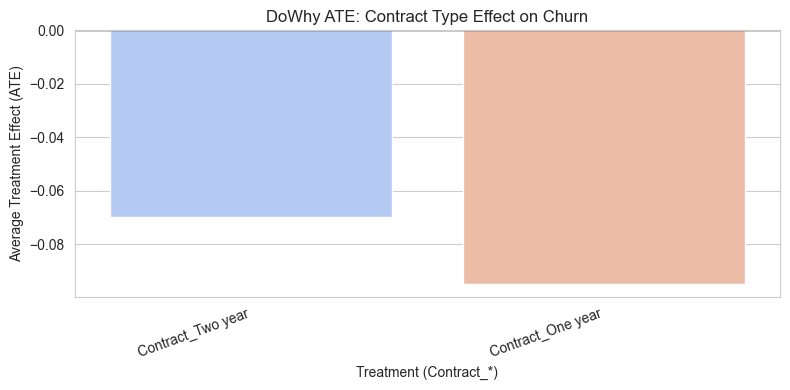

Interpretation: A negative ATE suggests that being in that contract type lowers churn probability on average, controlling for tenure and charges.


In [87]:
# DoWhy Step 2: Estimate ATE of each Contract_* treatment on churn
ate_rows = []

for treatment_col in contract_cols:
    work_df = causal_df[[treatment_col, "ChurnBin"] + confounder_cols].copy()

    # Skip degenerate binary treatment columns
    if work_df[treatment_col].nunique() < 2:
        continue

    model = CausalModel(
        data=work_df,
        treatment=treatment_col,
        outcome="ChurnBin",
        common_causes=confounder_cols,
    )

    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    estimate = model.estimate_effect(
        identified_estimand,
        method_name="backdoor.linear_regression",
        test_significance=True,
    )

    ate_rows.append({
        "Treatment": treatment_col,
        "ATE": float(estimate.value),
    })

if not ate_rows:
    raise ValueError("No valid Contract_* treatment columns available for ATE estimation.")

ate_df = pd.DataFrame(ate_rows).sort_values("ATE", ascending=False).reset_index(drop=True)
display(ate_df.round(6))

plt.figure(figsize=(8, 4))
sns.barplot(data=ate_df, x="Treatment", y="ATE", palette="coolwarm")
plt.axhline(0, color="black", linewidth=1)
plt.title("DoWhy ATE: Contract Type Effect on Churn")
plt.xlabel("Treatment (Contract_*)")
plt.ylabel("Average Treatment Effect (ATE)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print("Interpretation: A negative ATE suggests that being in that contract type lowers churn probability on average, controlling for tenure and charges.")

## Uplift Modeling (Causal): Contract + Payment Method -> Churn
Identify customers who are likely to respond only to intervention using individual uplift estimates.

In [88]:
# Uplift Step 1: Build treatment/outcome and estimate per-customer uplift (DR learner)
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

if "df_raw" in globals():
    uplift_base = df_raw.copy()
elif "df" in globals():
    uplift_base = df.copy()
else:
    uplift_base = pd.read_csv("telco_churn_processed.csv")

if "Churn" not in uplift_base.columns:
    raise ValueError("Column 'Churn' is required for uplift modeling.")

work = uplift_base.copy()
work["ChurnBin"] = work["Churn"].astype(str).str.strip().str.lower().map({
    "yes": 1, "true": 1, "1": 1,
    "no": 0, "false": 0, "0": 0
})
work = work.dropna(subset=["ChurnBin"]).copy()
work["Y_stay"] = 1 - work["ChurnBin"].astype(int)

# Robust handling for both raw and one-hot encoded schema
contract_raw_exists = "Contract" in work.columns
payment_raw_exists = "PaymentMethod" in work.columns
contract_dummy_cols = [c for c in work.columns if c.startswith("Contract_")]
payment_dummy_cols = [c for c in work.columns if c.startswith("PaymentMethod_")]

if contract_raw_exists:
    contract_str = work["Contract"].astype(str).str.lower()
    long_contract = contract_str.str.contains("one year|two year", regex=True)
elif contract_dummy_cols:
    two_year_col = next((c for c in contract_dummy_cols if "two year" in c.lower()), None)
    one_year_col = next((c for c in contract_dummy_cols if "one year" in c.lower()), None)
    long_contract = pd.Series(False, index=work.index)
    if two_year_col is not None:
        long_contract = long_contract | (work[two_year_col].fillna(0).astype(float) > 0.5)
    if one_year_col is not None:
        long_contract = long_contract | (work[one_year_col].fillna(0).astype(float) > 0.5)
else:
    raise ValueError("Neither raw 'Contract' nor encoded 'Contract_*' columns found.")

if payment_raw_exists:
    payment_str = work["PaymentMethod"].astype(str).str.lower()
    auto_pay = payment_str.str.contains("automatic", regex=False)
elif payment_dummy_cols:
    auto_cols = [c for c in payment_dummy_cols if "automatic" in c.lower()]
    if not auto_cols:
        raise ValueError("Encoded payment columns found, but none indicate automatic payment.")
    auto_pay = (work[auto_cols].fillna(0).astype(float).sum(axis=1) > 0.5)
else:
    raise ValueError("Neither raw 'PaymentMethod' nor encoded 'PaymentMethod_*' columns found.")

work["T"] = (long_contract & auto_pay).astype(int)
treated_rate = work["T"].mean()
if treated_rate <= 0.02 or treated_rate >= 0.98:
    raise ValueError(
        f"Treatment prevalence is extreme ({treated_rate:.3f}); uplift is unstable. Adjust treatment definition."
    )

# Build display-friendly Contract and PaymentMethod columns for output
if contract_raw_exists:
    work["Contract_display"] = work["Contract"].astype(str)
elif contract_dummy_cols:
    contract_matrix = work[contract_dummy_cols].fillna(0).astype(float)
    top_contract = contract_matrix.idxmax(axis=1).str.replace("Contract_", "", regex=False)
    no_signal = (contract_matrix.sum(axis=1) <= 0)
    work["Contract_display"] = np.where(no_signal, "Unknown", top_contract)

if payment_raw_exists:
    work["Payment_display"] = work["PaymentMethod"].astype(str)
elif payment_dummy_cols:
    payment_matrix = work[payment_dummy_cols].fillna(0).astype(float)
    top_payment = payment_matrix.idxmax(axis=1).str.replace("PaymentMethod_", "", regex=False)
    no_signal = (payment_matrix.sum(axis=1) <= 0)
    work["Payment_display"] = np.where(no_signal, "Unknown", top_payment)

candidate_feature_cols = [
    "Contract", "PaymentMethod", "tenure", "MonthlyCharges", "TotalCharges",
    "InternetService", "OnlineSecurity", "TechSupport", "PaperlessBilling",
    "SeniorCitizen", "Partner", "Dependents"
]

# Fallback to encoded schema if raw columns are not available
if not contract_raw_exists:
    candidate_feature_cols.extend(contract_dummy_cols)
if not payment_raw_exists:
    candidate_feature_cols.extend(payment_dummy_cols)

feature_cols = [c for c in dict.fromkeys(candidate_feature_cols) if c in work.columns]
X_uplift = work[feature_cols].copy()

for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if c in X_uplift.columns:
        X_uplift[c] = pd.to_numeric(X_uplift[c], errors="coerce")

# Convert boolean features to int to avoid sklearn SimpleImputer bool dtype error
bool_cols_uplift = X_uplift.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_cols_uplift:
    X_uplift[bool_cols_uplift] = X_uplift[bool_cols_uplift].astype(int)

num_cols = X_uplift.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_uplift.columns if c not in num_cols]

prep = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

prop_model = Pipeline(steps=[
    ("prep", prep),
    ("clf", LogisticRegression(max_iter=3000, random_state=42))
])
prop_model.fit(X_uplift, work["T"])
e_hat = np.clip(prop_model.predict_proba(X_uplift)[:, 1], 0.03, 0.97)

outcome_model_treated = Pipeline(steps=[
    ("prep", prep),
    ("rf", RandomForestClassifier(
        n_estimators=500, min_samples_leaf=8, random_state=42, n_jobs=-1
    ))
])
outcome_model_control = Pipeline(steps=[
    ("prep", prep),
    ("rf", RandomForestClassifier(
        n_estimators=500, min_samples_leaf=8, random_state=42, n_jobs=-1
    ))
])

mask_t = work["T"] == 1
mask_c = work["T"] == 0
outcome_model_treated.fit(X_uplift.loc[mask_t], work.loc[mask_t, "Y_stay"])
outcome_model_control.fit(X_uplift.loc[mask_c], work.loc[mask_c, "Y_stay"])

mu1_hat = outcome_model_treated.predict_proba(X_uplift)[:, 1]
mu0_hat = outcome_model_control.predict_proba(X_uplift)[:, 1]

T_arr = work["T"].values.astype(float)
Y_arr = work["Y_stay"].values.astype(float)

uplift_dr = (mu1_hat - mu0_hat) + (T_arr * (Y_arr - mu1_hat) / e_hat) - ((1 - T_arr) * (Y_arr - mu0_hat) / (1 - e_hat))

id_col = "customerID" if "customerID" in work.columns else None
uplift_results_df = pd.DataFrame({
    "customerID": work[id_col].astype(str).values if id_col is not None else work.index.astype(str),
    "Contract": work["Contract_display"].astype(str).values,
    "PaymentMethod": work["Payment_display"].astype(str).values,
    "Treated": work["T"].values.astype(int),
    "Stay_Observed": work["Y_stay"].values.astype(int),
    "P_stay_if_treated": mu1_hat,
    "P_stay_if_control": mu0_hat,
    "UpliftScore": uplift_dr,
})

uplift_results_df = uplift_results_df.sort_values("UpliftScore", ascending=False).reset_index(drop=True)
print(f"Rows scored: {len(uplift_results_df)}")
print(f"Treatment prevalence: {treated_rate:.3f}")
display(uplift_results_df.head(10).round(4))

Rows scored: 7043
Treatment prevalence: 0.139


,customerID,Contract,PaymentMethod,Treated,Stay_Observed,P_stay_if_treated,P_stay_if_control,UpliftScore
0,5947,Two year,Mailed check,0,0,0.9946,0.9266,1.0232
1,4819,Two year,Unknown,0,0,0.9903,0.9249,1.0189
2,2536,One year,Unknown,0,0,0.9913,0.8880,1.0188
3,268,Two year,Mailed check,0,0,0.9876,0.9207,1.0161
4,5670,Unknown,Mailed check,0,0,0.9884,0.8816,1.0156
5,4642,Two year,Unknown,0,0,0.9874,0.9098,1.0155
6,6398,Two year,Unknown,0,0,0.9892,0.8339,1.0150
7,4539,Two year,Electronic check,0,0,0.9868,0.8803,1.0141
8,6424,Two year,Electronic check,0,0,0.9865,0.8540,1.0129
9,1944,Unknown,Mailed check,0,0,0.9866,0.8214,1.0120


,Segment,Customers
0,Sure Thing (Stays Anyway),4355
1,Movable / Uncertain,2073
2,Persuadable (Intervention-Only Responder),608
3,Do Not Disturb (Possible Adverse Response),7


Top customers to target (highest expected gain from intervention):


,customerID,Contract,PaymentMethod,Treated,Stay_Observed,P_stay_if_treated,P_stay_if_control,UpliftScore,UpliftSegment
0,2295,Unknown,Electronic check,0,0,0.9782,0.3175,0.9880,Persuadable (Intervention-Only Responder)
1,185,Unknown,Electronic check,0,0,0.9764,0.3391,0.9869,Persuadable (Intervention-Only Responder)
2,5214,Unknown,Unknown,0,0,0.9758,0.3490,0.9866,Persuadable (Intervention-Only Responder)
3,2084,Unknown,Unknown,0,0,0.9769,0.2858,0.9858,Persuadable (Intervention-Only Responder)
4,3294,Unknown,Mailed check,0,0,0.9757,0.3073,0.9852,Persuadable (Intervention-Only Responder)
5,6612,Unknown,Mailed check,0,0,0.9757,0.2949,0.9849,Persuadable (Intervention-Only Responder)
6,7018,Unknown,Mailed check,0,0,0.9740,0.2902,0.9830,Persuadable (Intervention-Only Responder)
7,1851,Unknown,Electronic check,0,0,0.9723,0.3163,0.9821,Persuadable (Intervention-Only Responder)
8,4228,Unknown,Electronic check,0,0,0.9742,0.2510,0.9820,Persuadable (Intervention-Only Responder)
9,4640,Unknown,Electronic check,0,0,0.9757,0.1934,0.9817,Persuadable (Intervention-Only Responder)


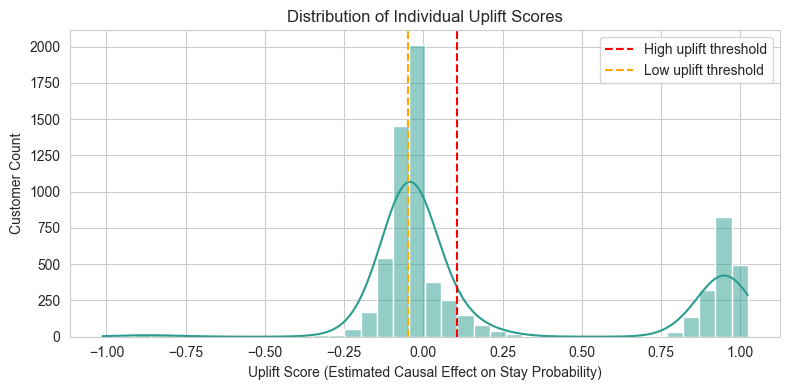

In [89]:
# Uplift Step 2: Segment customers and produce intervention target list
uplift_seg = uplift_results_df.copy()

# Segment thresholds
q_hi = uplift_seg["UpliftScore"].quantile(0.70)
q_lo = uplift_seg["UpliftScore"].quantile(0.30)
stay_hi = 0.70
stay_lo = 0.35

def assign_segment(row):
    p1 = row["P_stay_if_treated"]
    p0 = row["P_stay_if_control"]
    u = row["UpliftScore"]

    if u >= q_hi and p0 <= stay_lo and p1 >= stay_hi:
        return "Persuadable (Intervention-Only Responder)"
    if p0 >= stay_hi and p1 >= stay_hi:
        return "Sure Thing (Stays Anyway)"
    if p0 <= stay_lo and p1 <= stay_lo:
        return "Lost Cause (Churns Anyway)"
    if u <= q_lo and p0 >= stay_hi and p1 <= p0:
        return "Do Not Disturb (Possible Adverse Response)"
    return "Movable / Uncertain"

uplift_seg["UpliftSegment"] = uplift_seg.apply(assign_segment, axis=1)

# Primary targeting list: currently untreated persuadables
target_df = uplift_seg[
    (uplift_seg["Treated"] == 0)
    & (uplift_seg["UpliftSegment"] == "Persuadable (Intervention-Only Responder)")
].copy()

target_df = target_df.sort_values("UpliftScore", ascending=False).reset_index(drop=True)

segment_counts = uplift_seg["UpliftSegment"].value_counts().rename_axis("Segment").reset_index(name="Customers")
display(segment_counts)

print("Top customers to target (highest expected gain from intervention):")
display(target_df.head(25).round(4))

plt.figure(figsize=(8, 4))
sns.histplot(uplift_seg["UpliftScore"], bins=40, kde=True, color="#2a9d8f")
plt.axvline(q_hi, color="red", linestyle="--", linewidth=1.5, label="High uplift threshold")
plt.axvline(q_lo, color="orange", linestyle="--", linewidth=1.5, label="Low uplift threshold")
plt.title("Distribution of Individual Uplift Scores")
plt.xlabel("Uplift Score (Estimated Causal Effect on Stay Probability)")
plt.ylabel("Customer Count")
plt.legend()
plt.tight_layout()
plt.show()

LBSM state count selected by BIC: 6


,n_states,BIC
0,6,-74349.923569
1,5,-71800.894642
2,4,-54605.907468
3,3,-46750.160684


Latent lifecycle state summary:


,LBSM_State,LatentLifecycleState,Customers,AvgTenure,AvgMonthlyCharges,ChurnRate
0,1,AtRisk,1590,-0.7797,0.7032,0.5623
1,4,Early,24,-0.0100,-0.7463,0.0417
2,5,Growth,522,0.3298,0.9769,0.3103
3,2,Loyal,1409,1.2471,0.9866,0.1285
4,0,Mature,2007,0.4690,-0.8895,0.0683
5,3,Onboarding,1491,-1.0936,-0.8149,0.3313


Per-customer latent state table (top 30):


,customerID,LBSM_State,LatentLifecycleState,tenure,MonthlyCharges,ChurnBin
0,0,3,Onboarding,-1.2774,-1.1603,0
1,1,0,Mature,0.0663,-0.2596,0
2,2,3,Onboarding,-1.2367,-0.3627,1
3,3,0,Mature,0.5143,-0.7465,0
4,4,1,AtRisk,-1.2367,0.1974,1
5,5,1,AtRisk,-0.9924,1.1595,1
6,6,1,AtRisk,-0.4223,0.8089,0
7,7,3,Onboarding,-0.9110,-1.1636,0
8,8,1,AtRisk,-0.1780,1.3307,1
9,9,0,Mature,1.2065,-0.2862,0


C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\3985270141.py:139: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=lbsm_states_df, x="LatentLifecycleState", order=lbsm_states_df["LatentLifecycleState"].value_counts().index, palette="Set2")


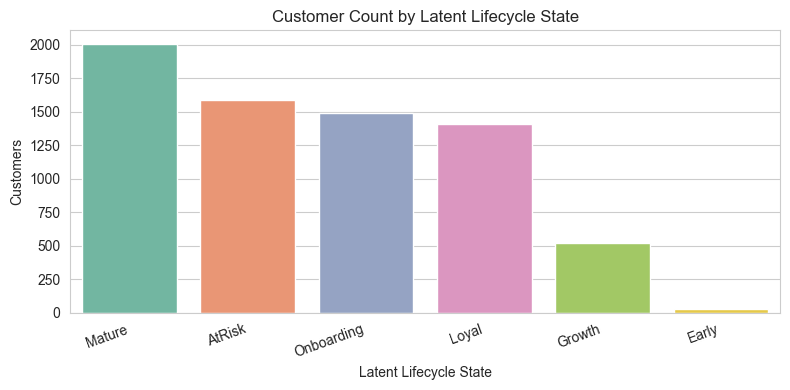

C:\Users\Pratham\AppData\Local\Temp\ipykernel_7424\3985270141.py:150: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_churn, x="LatentLifecycleState", y="ChurnBin", palette="coolwarm")


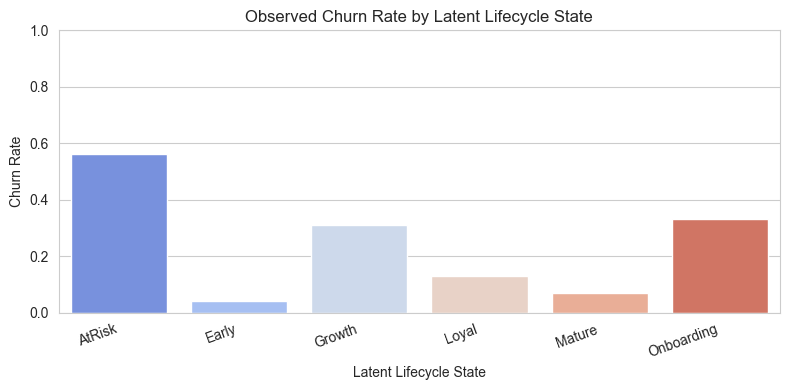

In [90]:
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

# Base dataset
if "df_raw" in globals():
    lbsm_df = df_raw.copy()
elif "df" in globals():
    lbsm_df = df.copy()
else:
    lbsm_df = pd.read_csv("telco_churn_processed.csv")

# Robust target conversion for churn profile by state
if "Churn" in lbsm_df.columns:
    lbsm_df["ChurnBin"] = lbsm_df["Churn"].astype(str).str.strip().str.lower().map({
        "yes": 1, "true": 1, "1": 1,
        "no": 0, "false": 0, "0": 0
    })
else:
    lbsm_df["ChurnBin"] = np.nan

# Lifecycle-relevant features
for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if col in lbsm_df.columns:
        lbsm_df[col] = pd.to_numeric(lbsm_df[col], errors="coerce")

if "TotalCharges" not in lbsm_df.columns and {"tenure", "MonthlyCharges"}.issubset(lbsm_df.columns):
    lbsm_df["TotalCharges"] = lbsm_df["tenure"].fillna(0) * lbsm_df["MonthlyCharges"].fillna(0)

lbsm_df["AvgMonthlyValue"] = (
    lbsm_df["TotalCharges"] / lbsm_df["tenure"].replace(0, np.nan)
).fillna(lbsm_df["MonthlyCharges"] if "MonthlyCharges" in lbsm_df.columns else 0)

if "MonthlyCharges" in lbsm_df.columns:
    med_bill = float(lbsm_df["MonthlyCharges"].median())
    lbsm_df["HighBillFlag"] = (lbsm_df["MonthlyCharges"] >= med_bill).astype(int)
else:
    lbsm_df["HighBillFlag"] = 0

state_features = [c for c in ["tenure", "MonthlyCharges", "TotalCharges", "AvgMonthlyValue", "HighBillFlag"] if c in lbsm_df.columns]
if len(state_features) < 3:
    raise ValueError(f"Insufficient lifecycle features for LBSM. Found: {state_features}")

lbsm_model_df = lbsm_df[state_features].copy()
lbsm_model_df = lbsm_model_df.replace([np.inf, -np.inf], np.nan)
lbsm_model_df = lbsm_model_df.fillna(lbsm_model_df.median(numeric_only=True))

scaler_lbsm = StandardScaler()
X_lbsm = scaler_lbsm.fit_transform(lbsm_model_df)

# Select number of latent states by BIC
candidate_states = [3, 4, 5, 6]
bic_rows = []
for k in candidate_states:
    gm_tmp = GaussianMixture(n_components=k, covariance_type="full", random_state=42)
    gm_tmp.fit(X_lbsm)
    bic_rows.append({"n_states": k, "BIC": gm_tmp.bic(X_lbsm)})

bic_df = pd.DataFrame(bic_rows).sort_values("BIC", ascending=True).reset_index(drop=True)
best_states = int(bic_df.loc[0, "n_states"])

lbsm_model = GaussianMixture(n_components=best_states, covariance_type="full", random_state=42)
latent_state = lbsm_model.fit_predict(X_lbsm)
lbsm_df["LBSM_State"] = latent_state

# Build business-friendly lifecycle labels
state_profile = (
    lbsm_df.groupby("LBSM_State")
    .agg(
        Customers=("LBSM_State", "size"),
        AvgTenure=("tenure", "mean") if "tenure" in lbsm_df.columns else ("LBSM_State", "size"),
        AvgMonthlyCharges=("MonthlyCharges", "mean") if "MonthlyCharges" in lbsm_df.columns else ("LBSM_State", "size"),
        ChurnRate=("ChurnBin", "mean")
    )
    .reset_index()
)

if "AvgTenure" not in state_profile.columns:
    state_profile["AvgTenure"] = np.nan
if "AvgMonthlyCharges" not in state_profile.columns:
    state_profile["AvgMonthlyCharges"] = np.nan

# Determine one explicit at-risk state by churn rate
if state_profile["ChurnRate"].notna().any():
    at_risk_state = int(state_profile.sort_values("ChurnRate", ascending=False).iloc[0]["LBSM_State"])
else:
    at_risk_state = None

other_states = state_profile[state_profile["LBSM_State"] != at_risk_state].copy() if at_risk_state is not None else state_profile.copy()
other_states = other_states.sort_values("AvgTenure", ascending=True)

def lifecycle_name_by_rank(rank, total):
    if total == 1:
        return "Growth"
    if total == 2:
        return ["Early", "Mature"][rank]
    if total == 3:
        return ["Early", "Growth", "Mature"][rank]
    return ["Onboarding", "Early", "Growth", "Mature", "Loyal"][min(rank, 4)]

state_to_label = {}
for i, row in other_states.reset_index(drop=True).iterrows():
    state_to_label[int(row["LBSM_State"])] = lifecycle_name_by_rank(i, len(other_states))

if at_risk_state is not None:
    state_to_label[at_risk_state] = "AtRisk"

lbsm_df["LatentLifecycleState"] = lbsm_df["LBSM_State"].map(state_to_label).fillna("Unknown")

id_col = "customerID" if "customerID" in lbsm_df.columns else None
lbsm_states_df = pd.DataFrame({
    "customerID": lbsm_df[id_col].astype(str).values if id_col is not None else lbsm_df.index.astype(str),
    "LBSM_State": lbsm_df["LBSM_State"].astype(int),
    "LatentLifecycleState": lbsm_df["LatentLifecycleState"].astype(str),
    "tenure": lbsm_df["tenure"] if "tenure" in lbsm_df.columns else np.nan,
    "MonthlyCharges": lbsm_df["MonthlyCharges"] if "MonthlyCharges" in lbsm_df.columns else np.nan,
    "ChurnBin": lbsm_df["ChurnBin"],
})

lbsm_state_summary = (
    lbsm_states_df.groupby(["LBSM_State", "LatentLifecycleState"], as_index=False)
    .agg(
        Customers=("customerID", "size"),
        AvgTenure=("tenure", "mean"),
        AvgMonthlyCharges=("MonthlyCharges", "mean"),
        ChurnRate=("ChurnBin", "mean")
    )
    .sort_values(["LatentLifecycleState", "ChurnRate"], ascending=[True, False])
    .reset_index(drop=True)
)

print("LBSM state count selected by BIC:", best_states)
display(bic_df)
print("Latent lifecycle state summary:")
display(lbsm_state_summary.round(4))
print("Per-customer latent state table (top 30):")
display(lbsm_states_df.head(30).round(4))

plt.figure(figsize=(8, 4))
sns.countplot(data=lbsm_states_df, x="LatentLifecycleState", order=lbsm_states_df["LatentLifecycleState"].value_counts().index, palette="Set2")
plt.title("Customer Count by Latent Lifecycle State")
plt.xlabel("Latent Lifecycle State")
plt.ylabel("Customers")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

plot_churn = lbsm_states_df.dropna(subset=["ChurnBin"]).groupby("LatentLifecycleState", as_index=False)["ChurnBin"].mean()
if not plot_churn.empty:
    plt.figure(figsize=(8, 4))
    sns.barplot(data=plot_churn, x="LatentLifecycleState", y="ChurnBin", palette="coolwarm")
    plt.title("Observed Churn Rate by Latent Lifecycle State")
    plt.xlabel("Latent Lifecycle State")
    plt.ylabel("Churn Rate")
    plt.ylim(0, 1)
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()
    plt.show()

## Reinforcement Learning (PPO): Optimal Retention Offer Policy
Train a PPO policy to decide which offer to give to which customer at what decision time, using customer features and churn feedback-driven rewards.

In [91]:
# PPO Step 1: Build RL environment from churn feedback and train policy
import warnings
warnings.filterwarnings("ignore")

# Auto-install if missing
try:
    import gymnasium as gym
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "gymnasium", "-q"] )
    import gymnasium as gym

try:
    from stable_baselines3 import PPO
except ImportError:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "stable-baselines3", "-q"] )
    from stable_baselines3 import PPO

from gymnasium import spaces
from sklearn.linear_model import LogisticRegression
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

np.random.seed(42)

# Base data (prefer raw schema)
if "df_raw" in globals():
    rl_df = df_raw.copy()
elif "df" in globals():
    rl_df = df.copy()
else:
    rl_df = pd.read_csv("telco_churn_processed.csv")

if "Churn" not in rl_df.columns:
    raise ValueError("Column 'Churn' is required for PPO retention policy.")

# Churn feedback target
rl_df["ChurnBin"] = rl_df["Churn"].astype(str).str.strip().str.lower().map({
    "yes": 1, "true": 1, "1": 1,
    "no": 0, "false": 0, "0": 0
})
rl_df = rl_df.dropna(subset=["ChurnBin"]).copy()
rl_df["StayBin"] = 1 - rl_df["ChurnBin"].astype(int)

# Candidate features (use all available after dropping ID/target columns)
drop_cols = [c for c in ["Churn", "ChurnBin", "StayBin", "customerID"] if c in rl_df.columns]
X_rl_raw = rl_df.drop(columns=drop_cols).copy()

# Normalize booleans to int
bool_cols = X_rl_raw.select_dtypes(include=["bool", "boolean"]).columns.tolist()
if bool_cols:
    X_rl_raw[bool_cols] = X_rl_raw[bool_cols].astype(int)

for c in ["tenure", "MonthlyCharges", "TotalCharges"]:
    if c in X_rl_raw.columns:
        X_rl_raw[c] = pd.to_numeric(X_rl_raw[c], errors="coerce")

num_cols = X_rl_raw.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_rl_raw.columns if c not in num_cols]

prep_rl = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols),
    ]
)

# Base churn risk model from observed churn feedback
base_model = Pipeline(steps=[
    ("prep", prep_rl),
    ("clf", LogisticRegression(max_iter=3000, random_state=42))
])
base_model.fit(X_rl_raw, rl_df["ChurnBin"] )
base_p_churn = np.clip(base_model.predict_proba(X_rl_raw)[:, 1], 0.01, 0.99)
base_p_stay = 1 - base_p_churn

# Dense state encoding for RL agent
X_rl_encoded = prep_rl.fit_transform(X_rl_raw)
if hasattr(X_rl_encoded, "toarray"):
    X_rl_encoded = X_rl_encoded.toarray()
X_rl_encoded = np.asarray(X_rl_encoded, dtype=np.float32)

# Time feature: decision points 0=early, 1=mid, 2=late
time_steps = np.array([0, 1, 2], dtype=np.int32)
time_multiplier = np.array([1.00, 1.10, 1.20], dtype=np.float32)

# Action space
offer_names = ["NoOffer", "Discount", "ContractUpgrade", "TechBundle"]
offer_cost = np.array([0.00, 0.04, 0.06, 0.05], dtype=np.float32)

# Build raw-feature helpers for treatment effects
if "Contract" in rl_df.columns:
    contract_text = rl_df["Contract"].astype(str).str.lower()
else:
    contract_text = pd.Series("unknown", index=rl_df.index)

if "PaymentMethod" in rl_df.columns:
    payment_text = rl_df["PaymentMethod"].astype(str).str.lower()
else:
    payment_text = pd.Series("unknown", index=rl_df.index)

if "InternetService" in rl_df.columns:
    internet_text = rl_df["InternetService"].astype(str).str.lower()
else:
    internet_text = pd.Series("unknown", index=rl_df.index)

tenure_raw = pd.to_numeric(rl_df["tenure"], errors="coerce") if "tenure" in rl_df.columns else pd.Series(12, index=rl_df.index)
monthly_raw = pd.to_numeric(rl_df["MonthlyCharges"], errors="coerce") if "MonthlyCharges" in rl_df.columns else pd.Series(70, index=rl_df.index)
monthly_thr = float(np.nanmedian(monthly_raw.fillna(monthly_raw.median())))

def action_uplift_delta(idx, action):
    # Heuristic uplift shaped by churn-related signals; bounded to avoid unrealistic effects.
    month_to_month = "month-to-month" in str(contract_text.iloc[idx]).lower()
    has_auto_pay = "automatic" in str(payment_text.iloc[idx]).lower()
    fiber_user = "fiber" in str(internet_text.iloc[idx]).lower()
    low_tenure = float(tenure_raw.iloc[idx] if pd.notna(tenure_raw.iloc[idx]) else 12) <= 12
    high_bill = float(monthly_raw.iloc[idx] if pd.notna(monthly_raw.iloc[idx]) else monthly_thr) >= monthly_thr

    if action == 0:
        delta = 0.00
    elif action == 1:  # Discount
        delta = 0.03 + (0.08 if high_bill else 0.02) + (0.02 if month_to_month else 0.00)
    elif action == 2:  # ContractUpgrade
        delta = 0.04 + (0.10 if month_to_month else 0.01) + (0.03 if low_tenure else 0.00)
    else:  # TechBundle
        delta = 0.03 + (0.07 if fiber_user else 0.01) + (0.02 if not has_auto_pay else 0.00)

    return float(np.clip(delta, -0.02, 0.18))

class RetentionOfferEnv(gym.Env):
    metadata = {"render_modes": []}

    def __init__(self, X_state, base_stay, n_time=3, episode_len=250):
        super().__init__()
        self.X_state = X_state
        self.base_stay = base_stay.astype(np.float32)
        self.n_customers = X_state.shape[0]
        self.n_time = n_time
        self.episode_len = episode_len
        self.step_count = 0

        obs_dim = X_state.shape[1] + 1  # + time scalar
        self.observation_space = spaces.Box(low=-5.0, high=5.0, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(len(offer_names))

        self.current_customer = 0
        self.current_time = 0

    def _build_obs(self):
        x = self.X_state[self.current_customer]
        t = np.array([self.current_time / max(self.n_time - 1, 1)], dtype=np.float32)
        return np.concatenate([x, t], axis=0).astype(np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        self.step_count = 0
        self.current_customer = np.random.randint(0, self.n_customers)
        self.current_time = np.random.randint(0, self.n_time)
        obs = self._build_obs()
        return obs, {}

    def step(self, action):
        idx = self.current_customer
        t = self.current_time

        base = float(self.base_stay[idx])
        delta = action_uplift_delta(idx, int(action)) * float(time_multiplier[t])
        p_stay = float(np.clip(base + delta, 0.01, 0.99))

        # Expected reward: stay benefit minus intervention cost
        reward = p_stay - float(offer_cost[int(action)])

        self.step_count += 1
        terminated = self.step_count >= self.episode_len
        truncated = False

        self.current_customer = np.random.randint(0, self.n_customers)
        self.current_time = np.random.randint(0, self.n_time)
        next_obs = self._build_obs()

        info = {"p_stay": p_stay, "customer_idx": idx, "time_step": int(t)}
        return next_obs, reward, terminated, truncated, info

env = RetentionOfferEnv(X_state=X_rl_encoded, base_stay=base_p_stay, n_time=3, episode_len=300)

ppo_model = PPO(
    policy="MlpPolicy",
    env=env,
    verbose=0,
    learning_rate=3e-4,
    n_steps=512,
    batch_size=128,
    gamma=0.99,
    gae_lambda=0.95,
    ent_coef=0.01,
    seed=42,
 )
ppo_model.learn(total_timesteps=20000)

print("PPO training complete.")
print(f"Customers used for RL: {len(rl_df)} | State dimension: {X_rl_encoded.shape[1]}")
print("Actions:", offer_names)

PPO training complete.
Customers used for RL: 7043 | State dimension: 30
Actions: ['NoOffer', 'Discount', 'ContractUpgrade', 'TechBundle']


Top policy recommendations:


,customerID,DecisionTime,RecommendedAction,ExpectedStayProb,ExpectedReward
0,2718,Early,NoOffer,0.9900,0.9900
1,5115,Early,NoOffer,0.9900,0.9900
2,5115,Late,NoOffer,0.9900,0.9900
3,6436,Late,NoOffer,0.9900,0.9900
4,5115,Mid,NoOffer,0.9900,0.9900
5,4772,Mid,NoOffer,0.9900,0.9900
6,1110,Late,NoOffer,0.9900,0.9900
7,4029,Late,NoOffer,0.9900,0.9900
8,1110,Mid,NoOffer,0.9900,0.9900
9,2718,Mid,NoOffer,0.9900,0.9900


Policy action mix (%):


RecommendedAction
Discount           38.37
TechBundle         26.07
ContractUpgrade    19.83
NoOffer            15.73
Name: Percent, dtype: float64

Best action-time pair per customer (top 25 shown):


,customerID,DecisionTime,RecommendedAction,ExpectedStayProb,ExpectedReward
0,1021,Late,ContractUpgrade,0.9900,0.9300
1,1031,Late,ContractUpgrade,0.8867,0.8267
2,1033,Early,Discount,0.9900,0.9500
3,1035,Mid,Discount,0.9900,0.9500
4,1039,Late,TechBundle,0.7992,0.7492
5,1043,Late,ContractUpgrade,0.7692,0.7092
6,1070,Late,ContractUpgrade,0.5501,0.4901
7,1071,Late,ContractUpgrade,0.7165,0.6565
8,1085,Mid,NoOffer,0.3525,0.3525
9,1110,Early,NoOffer,0.9900,0.9900


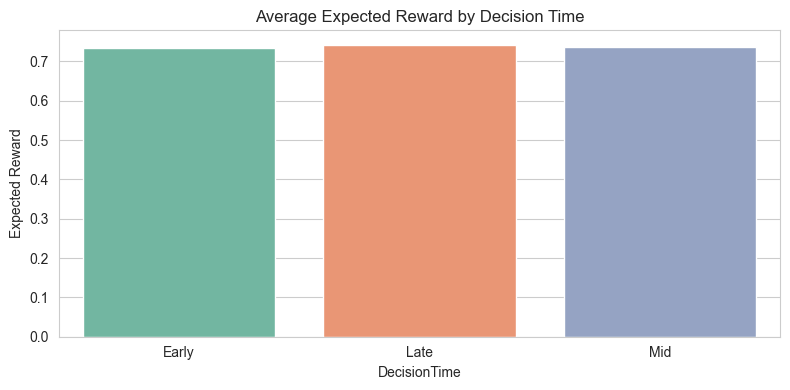

In [92]:
# PPO Step 2: Derive optimal action policy (which offer, which customer, what time)
time_label = {0: "Early", 1: "Mid", 2: "Late"}
id_series = rl_df["customerID"].astype(str) if "customerID" in rl_df.columns else rl_df.index.astype(str)

policy_rows = []
sample_n = min(1000, len(rl_df))
sample_idx = np.random.choice(np.arange(len(rl_df)), size=sample_n, replace=False)

for idx in sample_idx:
    for t in [0, 1, 2]:
        obs = np.concatenate([
            X_rl_encoded[idx],
            np.array([t / 2.0], dtype=np.float32)
        ]).astype(np.float32)

        action, _ = ppo_model.predict(obs, deterministic=True)
        action = int(action)

        base = float(base_p_stay[idx])
        delta = action_uplift_delta(idx, action) * float(time_multiplier[t])
        p_stay_policy = float(np.clip(base + delta, 0.01, 0.99))
        exp_reward = p_stay_policy - float(offer_cost[action])

        policy_rows.append({
            "customerID": id_series[idx],
            "DecisionTime": time_label[t],
            "RecommendedAction": offer_names[action],
            "ExpectedStayProb": p_stay_policy,
            "ExpectedReward": exp_reward,
        })

policy_df = pd.DataFrame(policy_rows).sort_values("ExpectedReward", ascending=False).reset_index(drop=True)

print("Top policy recommendations:")
display(policy_df.head(25).round(4))

action_mix = policy_df["RecommendedAction"].value_counts(normalize=True).mul(100).round(2).rename("Percent")
print("Policy action mix (%):")
display(action_mix)

# One recommendation per customer at best timing
best_customer_policy = policy_df.sort_values("ExpectedReward", ascending=False).groupby("customerID", as_index=False).first()
print("Best action-time pair per customer (top 25 shown):")
display(best_customer_policy.head(25).round(4))

plt.figure(figsize=(8, 4))
sns.barplot(
    data=policy_df.groupby("DecisionTime", as_index=False)["ExpectedReward"].mean(),
    x="DecisionTime", y="ExpectedReward", palette="Set2"
 )
plt.title("Average Expected Reward by Decision Time")
plt.ylabel("Expected Reward")
plt.tight_layout()
plt.show()

In [93]:
# PPO Step 3: Discount-only recommendation list
if "policy_df" not in globals():
    raise NameError("policy_df not found. Run the PPO policy generation cell first.")

discount_list = (
    policy_df[policy_df["RecommendedAction"] == "Discount"]
    .sort_values("ExpectedReward", ascending=False)
    .reset_index(drop=True)
)

print(f"Total discount recommendations: {len(discount_list)}")
display(discount_list.head(100).round(4))

Total discount recommendations: 1151


,customerID,DecisionTime,RecommendedAction,ExpectedStayProb,ExpectedReward
0,553,Mid,Discount,0.99,0.95
1,4227,Mid,Discount,0.99,0.95
2,6996,Late,Discount,0.99,0.95
3,6996,Mid,Discount,0.99,0.95
4,4256,Mid,Discount,0.99,0.95
...,...,...,...,...,...
95,3486,Late,Discount,0.99,0.95
96,3486,Mid,Discount,0.99,0.95
97,4009,Late,Discount,0.99,0.95
98,4009,Mid,Discount,0.99,0.95


In [94]:
# PPO Step 4: Retention Action table (discount / upgrade / skip)
if "policy_df" not in globals():
    raise NameError("policy_df not found. Run the PPO policy generation cell first.")

action_map = {
    "Discount": "discount",
    "ContractUpgrade": "upgrade",
    "NoOffer": "skip",
}

retention_action_df = policy_df.copy()
retention_action_df = retention_action_df[retention_action_df["RecommendedAction"].isin(action_map.keys())].copy()
retention_action_df["RetentionAction"] = retention_action_df["RecommendedAction"].map(action_map)

retention_action_df = retention_action_df[[
    "customerID",
    "DecisionTime",
    "RetentionAction",
    "ExpectedStayProb",
    "ExpectedReward",
]].sort_values("ExpectedReward", ascending=False).reset_index(drop=True)

print("Retention Action list (discount / upgrade / skip):")
display(retention_action_df.head(100).round(4))

print("Retention action mix (%):")
display(
    retention_action_df["RetentionAction"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .rename("Percent")
)

Retention Action list (discount / upgrade / skip):


,customerID,DecisionTime,RetentionAction,ExpectedStayProb,ExpectedReward
0,4029,Late,skip,0.9900,0.9900
1,4029,Mid,skip,0.9900,0.9900
2,1110,Early,skip,0.9900,0.9900
3,4029,Early,skip,0.9900,0.9900
4,2718,Late,skip,0.9900,0.9900
...,...,...,...,...,...
95,3363,Late,skip,0.9681,0.9681
96,3733,Late,skip,0.9672,0.9672
97,3733,Mid,skip,0.9672,0.9672
98,3733,Early,skip,0.9672,0.9672


Retention action mix (%):


RetentionAction
discount    51.89
upgrade     26.83
skip        21.28
Name: Percent, dtype: float64

A/B Test Result (Treatment = PPO action, Control = skip):


,Treatment_N,Control_N,Treatment_StayRate,Control_StayRate,Absolute_Uplift,Relative_Uplift_%,CI95_Low,CI95_High,Z_stat,P_value,Significant_5pct
0,503,497,0.7992,0.7264,0.0728,10.029,0.0203,0.1254,2.7085,0.0068,True


,AB_Group,ServedAction,N,StayRate,AvgReward
0,Control,NoOffer,497,0.7264,0.7264
1,Treatment,NoOffer,66,0.7576,0.7576
2,Treatment,Discount,190,0.9684,0.9284
3,Treatment,ContractUpgrade,104,0.6538,0.5938
4,Treatment,TechBundle,143,0.6993,0.6493


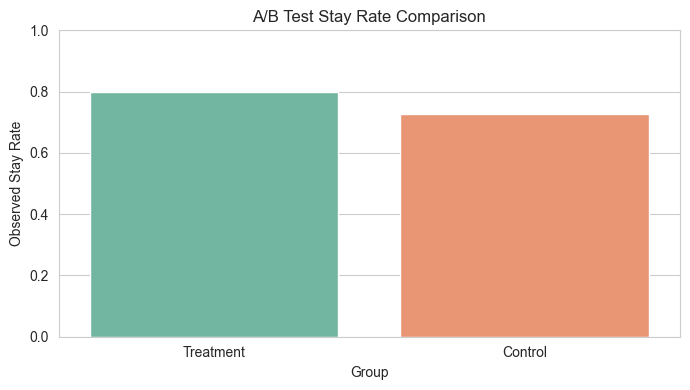

In [95]:
# PPO Step 5: Measure uplift with A/B test result
from scipy.stats import norm

if "policy_df" not in globals():
    raise NameError("policy_df not found. Run PPO policy cell first.")
if "action_uplift_delta" not in globals() or "base_p_stay" not in globals() or "offer_cost" not in globals() or "offer_names" not in globals():
    raise NameError("Required PPO variables are missing. Run PPO training/policy cells first.")

np.random.seed(42)

# One recommended action-time pair per customer (best expected reward)
ab_base = policy_df.sort_values("ExpectedReward", ascending=False).groupby("customerID", as_index=False).first().copy()

# Map recommended action to action index used in PPO environment
action_to_idx = {name: i for i, name in enumerate(offer_names)}
ab_base["action_idx"] = ab_base["RecommendedAction"].map(action_to_idx).astype(int)

# Randomized A/B assignment
ab_base["AB_Group"] = np.where(np.random.rand(len(ab_base)) < 0.5, "Treatment", "Control")

# Treatment = use recommended action. Control = skip (NoOffer)
skip_idx = action_to_idx.get("NoOffer", 0)
ab_base["served_action_idx"] = np.where(ab_base["AB_Group"] == "Treatment", ab_base["action_idx"], skip_idx).astype(int)

# Build customer index mapping to reuse PPO-derived uplift function
id_series_str = pd.Series(id_series).astype(str).reset_index(drop=True) if "id_series" in globals() else pd.Series(np.arange(len(base_p_stay)).astype(str))
id_to_idx = pd.Series(np.arange(len(id_series_str)), index=id_series_str.values).to_dict()
ab_base["idx"] = ab_base["customerID"].astype(str).map(id_to_idx)
ab_base = ab_base.dropna(subset=["idx"]).copy()
ab_base["idx"] = ab_base["idx"].astype(int)

# Simulate observed stay/churn outcome under assigned action
sim_stay_prob = []
sim_stay_obs = []
sim_reward = []
for _, row in ab_base.iterrows():
    i = int(row["idx"] )
    a = int(row["served_action_idx"] )
    base = float(base_p_stay[i])
    delta = float(action_uplift_delta(i, a))
    p_stay = float(np.clip(base + delta, 0.01, 0.99))
    y_stay = int(np.random.binomial(1, p_stay))
    reward = float(y_stay - float(offer_cost[a]))

    sim_stay_prob.append(p_stay)
    sim_stay_obs.append(y_stay)
    sim_reward.append(reward)

ab_base["SimStayProb"] = sim_stay_prob
ab_base["SimStayObserved"] = sim_stay_obs
ab_base["SimReward"] = sim_reward

# A/B metrics
treat = ab_base[ab_base["AB_Group"] == "Treatment"]
ctrl = ab_base[ab_base["AB_Group"] == "Control"]

n_t = len(treat)
n_c = len(ctrl)
p_t = float(treat["SimStayObserved"].mean()) if n_t > 0 else np.nan
p_c = float(ctrl["SimStayObserved"].mean()) if n_c > 0 else np.nan
uplift_abs = p_t - p_c
uplift_rel = uplift_abs / max(p_c, 1e-8)

# Two-proportion z-test + 95% CI
p_pool = ((p_t * n_t) + (p_c * n_c)) / max(n_t + n_c, 1)
se_pool = np.sqrt(max(p_pool * (1 - p_pool) * (1 / max(n_t, 1) + 1 / max(n_c, 1)), 1e-12))
z_stat = uplift_abs / se_pool
p_value = 2 * (1 - norm.cdf(abs(z_stat)))

se_ci = np.sqrt(max((p_t * (1 - p_t) / max(n_t, 1)) + (p_c * (1 - p_c) / max(n_c, 1)), 1e-12))
ci_low = uplift_abs - 1.96 * se_ci
ci_high = uplift_abs + 1.96 * se_ci

ab_summary = pd.DataFrame([
    {
        "Treatment_N": n_t,
        "Control_N": n_c,
        "Treatment_StayRate": p_t,
        "Control_StayRate": p_c,
        "Absolute_Uplift": uplift_abs,
        "Relative_Uplift_%": uplift_rel * 100,
        "CI95_Low": ci_low,
        "CI95_High": ci_high,
        "Z_stat": z_stat,
        "P_value": p_value,
        "Significant_5pct": p_value < 0.05,
    }
])

print("A/B Test Result (Treatment = PPO action, Control = skip):")
display(ab_summary.round(4))

# Breakdown by served action
action_breakdown = (
    ab_base.groupby(["AB_Group", "served_action_idx"])
    .agg(N=("SimStayObserved", "size"), StayRate=("SimStayObserved", "mean"), AvgReward=("SimReward", "mean"))
    .reset_index()
 )
action_breakdown["ServedAction"] = action_breakdown["served_action_idx"].map({i: n for i, n in enumerate(offer_names)})
display(action_breakdown[["AB_Group", "ServedAction", "N", "StayRate", "AvgReward"]].round(4))

plt.figure(figsize=(7, 4))
sns.barplot(
    data=pd.DataFrame({"Group": ["Treatment", "Control"], "StayRate": [p_t, p_c]}),
    x="Group", y="StayRate", palette="Set2"
)
plt.ylim(0, 1)
plt.title("A/B Test Stay Rate Comparison")
plt.ylabel("Observed Stay Rate")
plt.tight_layout()
plt.show()